In [27]:
# Copyright 2023 DeepMind Technologies Limited
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#    http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
# ==============================================================================

In [28]:
# Skip this cell if running from local environment
!pip install -q --no-warn-conflicts git+https://github.com/google-deepmind/nuclease_design.git
# After installing, restart the kernel
# Then run cells as normal


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [29]:
reference_seq = df.sequence.iloc[0]
print(len(reference_seq))
reference_seq

142


'MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASRYPETGAHISDAIKAGHADVCTIERSGADKRRQESLKGIPTKPGFDRDEWPMAMCEEGGKGASVRYVSSSDNRGAGSWVGNRLNGYADGTRILFIVQ'

# Imports

In [30]:
import itertools
import pandas as pd
import pathlib

from nuclease_design import utils
from nuclease_design import constants


# Load data

In [31]:
DATA_DIR = constants.DATA_DIR

In [32]:
LOCAL_OUTPUT_DIR = pathlib.Path('data')
LOCAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [33]:
%%time
all_data_df = utils.load_all_data(DATA_DIR)

CPU times: user 509 ms, sys: 145 ms, total: 654 ms
Wall time: 3.71 s


# Aggregate data across generations

In [34]:
# By sorting and aggregating the "first", we keep the activity label from the
# most recent generation
all_data_df['generations'] = all_data_df['generation']
all_data_df = all_data_df.sort_values(by='generation', ascending=False)  # order by generation
agg_dict = {
    'sublibrary_names': lambda x: tuple(itertools.chain.from_iterable(x)),
    'generations': lambda x: tuple(sorted(x)),
    'activity_greater_than_neg_control': 'first',
    'activity_greater_than_wt': 'first',
    'activity_greater_than_a73r': 'first',
    'num_mutations': 'first',
    'sequence': 'first',
}
df = all_data_df.groupby('mutations').agg(agg_dict).reset_index()

In [35]:
# Use the highest activity level found in the most recent generation.
def find_highest_activity_level(row, default_label='non-functional'):
  references = ['neg_control', 'wt', 'a73r']
  cols = [f'activity_greater_than_{ref}' for ref in references]
  true_indices = [
      i for i, col in enumerate(cols) if row[col] is not None and row[col]
  ]
  if not true_indices:
    return default_label
  if tuple(true_indices) == (1,):  # label as nonfunctional variants that fail the negative control test,
    return default_label
  else:
    return cols[max(true_indices)]


df['activity_level'] = (
    df.apply(find_highest_activity_level, axis=1)
    .str.replace('a73r', 'A73R')
    .str.replace('a73r', 'A73R')
    .str.replace('wt', 'WT')
    .str.replace('neg_control', '0')
)
df['is_functional'] = df['activity_level'] != 'non-functional'

In [36]:
df.sublibrary_names.value_counts()

sublibrary_names
(g1_eppcr,)                                                                                7770
(g3_unmatched,)                                                                            7608
(g4_other,)                                                                                4371
(g2_unmatched,)                                                                            4317
(g2_mbo_dnn_explore,)                                                                      4045
                                                                                           ... 
(g3_prosar_high_screen_low, g2_unmatched)                                                     1
(g4_g3_hit_constituents, g3_prosar_high_unscreened)                                           1
(g4_g3_plate_assay_variants, g4_mbo_seeds, g2_mbo_dnn_explore)                                1
(zero_shot, g3_g1_stratified_sample, g2_single_mutants, g2_stratified_sample, g1_eppcr)       1
(g3_hit_recombination, 

In [37]:
df

,mutations,sublibrary_names,generations,activity_greater_than_neg_control,activity_greater_than_wt,activity_greater_than_a73r,num_mutations,sequence,activity_level,is_functional
0,(),"(g4_mbo_seeds, g4_wt_synonyms, g3_wt_synonyms,...","(g1, g2, g3, g4)",True,False,False,0,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,activity_greater_than_0,True
1,"((A, 30, S),)","(g1_eppcr,)","(g1,)",True,False,None,1,MIKKWAVHLLFSALVLLGLSGGAAYSPQHSEGAARYDDVLYFPASR...,activity_greater_than_0,True
2,"((A, 30, S), (D, 91, A), (E, 94, A), (N, 117, A))","(g1_eppcr,)","(g1,)",False,False,None,4,MIKKWAVHLLFSALVLLGLSGGAAYSPQHSEGAARYDDVLYFPASR...,non-functional,False
3,"((A, 30, T),)","(g2_unmatched, g1_eppcr)","(g1, g2)",True,False,None,1,MIKKWAVHLLFSALVLLGLSGGAAYSPQHTEGAARYDDVLYFPASR...,activity_greater_than_0,True
4,"((A, 30, T), (D, 91, A), (E, 94, A), (N, 117, A))","(g1_eppcr,)","(g1,)",False,False,None,4,MIKKWAVHLLFSALVLLGLSGGAAYSPQHTEGAARYDDVLYFPASR...,non-functional,False
...,...,...,...,...,...,...,...,...,...,...
55755,"((Y, 131, S),)","(g1_eppcr,)","(g1,)",False,False,None,1,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,False
55756,"((Y, 131, T),)","(g3_single_mutants, g1_eppcr)","(g1, g3)",False,False,False,1,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,False
55757,"((Y, 131, V),)","(g3_single_mutants, g1_eppcr)","(g1, g3)",True,False,False,1,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,activity_greater_than_0,True
55758,"((Y, 131, W),)","(g3_single_mutants,)","(g3,)",False,False,False,1,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,False


In [38]:
cols_to_keep = [
    'mutations',
    'num_mutations',
    'sublibrary_names',
    'generations',
    'activity_level',
    'is_functional',
    'sequence',
]

In [39]:
output_path = LOCAL_OUTPUT_DIR / pathlib.Path(constants.LANDSCAPE_PATH)
output_path.parent.mkdir(parents=True, exist_ok=True)

with utils.open_file(constants.LANDSCAPE_PATH, 'w', LOCAL_OUTPUT_DIR) as f:
  utils.encode_df(df[cols_to_keep]).to_csv(f, index=False)

# Conflicting labels across generations

In [40]:
order = ['non-functional', 'activity_greater_than_0', 'activity_greater_than_WT', 'activity_greater_than_A73R']

Note that some variants have conflicting functional labels:

For the hypothesis tests corresponding to [neg_control, wt, a73r], there were were 5 variants with [F, T, T] (labeled as activity > A73R), and 973 variants with [F, T, F] (labeled as non-functional).

In [41]:
pd.crosstab(df['activity_level'], df['activity_greater_than_neg_control']).reindex(order)

activity_greater_than_neg_control,False,True
activity_level,,
non-functional,33890,0
activity_greater_than_0,0,11099
activity_greater_than_WT,0,10572
activity_greater_than_A73R,5,194


In [42]:
pd.crosstab(df['activity_level'], df['activity_greater_than_wt']).reindex(order)

activity_greater_than_wt,False,True
activity_level,,
non-functional,32917,973
activity_greater_than_0,11099,0
activity_greater_than_WT,0,10572
activity_greater_than_A73R,0,199


In [43]:
pd.crosstab(df['activity_level'], df['activity_greater_than_a73r']).reindex(order)

activity_greater_than_a73r,False,True
activity_level,,
non-functional,15189,0
activity_greater_than_0,8442,0
activity_greater_than_WT,9941,0
activity_greater_than_A73R,0,199


In [44]:
df[['activity_greater_than_neg_control', 'activity_greater_than_wt', 'activity_greater_than_a73r']].value_counts()

activity_greater_than_neg_control  activity_greater_than_wt  activity_greater_than_a73r
False                              False                     False                         14216
True                               True                      False                          9941
                                   False                     False                          8442
False                              True                      False                           973
True                               True                      True                            194
False                              True                      True                              5
Name: count, dtype: int64

In [45]:
# 20K variants were not assessed for activity relative to A73R
# these correspond to variants seen only in g1/g2.
df[df['activity_greater_than_a73r'].isna()].generations.explode().value_counts()

generations
g2    14219
g1     8670
Name: count, dtype: int64

In [46]:
# 5 variants conflict in their a73r + wt vs neg_control label.
df[df['activity_greater_than_a73r'] & df['activity_greater_than_wt'] & ~df['activity_greater_than_neg_control']].generations.value_counts()

generations
(g3,)    4
(g4,)    1
Name: count, dtype: int64

In [47]:
# 973 variants conflict in their wt vs neg_control label.
df[df['activity_greater_than_wt'] & ~df['activity_greater_than_neg_control']].generations.value_counts()

generations
(g4,)           660
(g3,)           303
(g2, g4)          3
(g1, g2, g4)      3
(g1, g3)          3
(g3, g4)          2
(g2, g3)          2
(g1, g3, g4)      1
(g2, g3, g4)      1
Name: count, dtype: int64

# MC exploration

In [48]:
df.generations.value_counts()

generations
(g3,)               17627
(g4,)               15008
(g2,)               13319
(g1,)                7770
(g1, g2)              900
(g1, g3)              463
(g2, g3)              177
(g3, g4)              145
(g1, g2, g4)          101
(g1, g2, g3)          100
(g1, g3, g4)           55
(g1, g2, g3, g4)       38
(g2, g4)               30
(g1, g4)               14
(g2, g3, g4)           13
Name: count, dtype: int64

In [49]:
for generation in df.generations.unique():
    test = df[df['generations']==generation].activity_level.value_counts()
    print(generation,'\n',test)

('g1', 'g2', 'g3', 'g4') 
 activity_level
activity_greater_than_0     20
activity_greater_than_WT    13
non-functional               5
Name: count, dtype: int64
('g1',) 
 activity_level
non-functional              7330
activity_greater_than_0      386
activity_greater_than_WT      54
Name: count, dtype: int64
('g1', 'g2') 
 activity_level
non-functional              726
activity_greater_than_0     162
activity_greater_than_WT     12
Name: count, dtype: int64
('g3',) 
 activity_level
non-functional                6346
activity_greater_than_0       5955
activity_greater_than_WT      5171
activity_greater_than_A73R     155
Name: count, dtype: int64
('g4',) 
 activity_level
non-functional                8410
activity_greater_than_WT      4496
activity_greater_than_0       2060
activity_greater_than_A73R      42
Name: count, dtype: int64
('g1', 'g3') 
 activity_level
non-functional              281
activity_greater_than_0     174
activity_greater_than_WT      8
Name: count, dtype: int64
('g

In [58]:
test.sort_values(by = 'mutation_string', ascending=False)

,sequence,activity_level,mutation_string,mutated_residues,mutated_positions,Y25,S26,P27,Q28,H29,...,D133,G134,T135,R136,I137,L138,F139,I140,V141,Q142
46180,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,YYYYYYR,"Y,Y,Y,Y,Y,Y,R","136,137,138,139,140,141,142",Y,S,P,Q,H,...,D,G,T,Y,Y,Y,Y,Y,Y,R
28860,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,YYYSIESQ,"Y,Y,Y,S,I,E,S,Q","62,63,73,87,110,115,120,122",Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
28299,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,YYYNI,"Y,Y,Y,N,I","53,60,63,114,123",Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
37345,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,YYYDVV,"Y,Y,Y,D,V,V","126,127,128,129,138,140",Y,S,P,Q,H,...,D,G,T,R,I,V,F,V,V,Q
18449,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,YYY,"Y,Y,Y","56,105,114",Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37275,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,activity_greater_than_0,A,A,126,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
37346,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,activity_greater_than_0,A,A,129,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
37441,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFAASR...,non-functional,A,A,43,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
37674,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,A,A,48,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q


In [56]:
test = parse_mutations(
    seq_column=df.sequence,
    reference=df.sequence.iloc[0],
    start_num=1,
    df=df,         
    fitness_column="activity_level",                 # activity_level pulled automatically
    extra_cols=["batch", "round"],  # any other columns you want along for the ride
)
test

,sequence,activity_level,mutation_string,mutated_residues,mutated_positions,Y25,S26,P27,Q28,H29,...,D133,G134,T135,R136,I137,L138,F139,I140,V141,Q142
0,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,activity_greater_than_0,,,,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
1,MIKKWAVHLLFSALVLLGLSGGAAYSPQHSEGAARYDDVLYFPASR...,activity_greater_than_0,S,S,30,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
2,MIKKWAVHLLFSALVLLGLSGGAAYSPQHSEGAARYDDVLYFPASR...,non-functional,SAAA,"S,A,A,A","30,91,94,117",Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
3,MIKKWAVHLLFSALVLLGLSGGAAYSPQHTEGAARYDDVLYFPASR...,activity_greater_than_0,T,T,30,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
4,MIKKWAVHLLFSALVLLGLSGGAAYSPQHTEGAARYDDVLYFPASR...,non-functional,TAAA,"T,A,A,A","30,91,94,117",Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55755,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,S,S,131,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
55756,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,T,T,131,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
55757,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,activity_greater_than_0,V,V,131,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
55758,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,W,W,131,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q


In [77]:
def parse_mutations(
    seq_column: pd.Series,
    reference: str,
    start_num: int = 1,
    df: pd.DataFrame = None,
    fitness_column: str = "activity_level",
    extra_cols: list = None,
) -> pd.DataFrame:
    """
    Compare protein sequences against a reference and extract mutation information.

    Parameters
    ----------
    seq_column   : pd.Series of protein sequences (all must be same length as reference)
    reference    : reference/parent protein sequence string
    start_num    : residue number assigned to the first position (default: 1)
    df           : original dataframe — if provided, 'activity_level' is carried over
                   automatically; use extra_cols to pull additional columns too
    extra_cols   : additional column names from df to carry over (e.g. ["batch", "round"])
    """
    ref       = reference.upper()
    sequences = seq_column.str.upper().reset_index(drop=True)

    # Columns to carry over from the original dataframe
    carry = []
    if df is not None:
        if fitness_column in df.columns:
            carry.append("activity_level")
        if extra_cols:
            carry += [c for c in extra_cols if c in df.columns and c not in carry]
    
    carry_data = {}
    if df is not None and carry:
        for col in carry:
            carry_data[col] = df[col].reset_index(drop=True)

    # Find every position mutated in at least one sequence
    all_mut_positions = set()
    for seq in sequences:
        if len(seq) != len(ref):
            raise ValueError(
                f"Sequence length {len(seq)} does not match reference length {len(ref)}."
            )
        for i, (ref_aa, seq_aa) in enumerate(zip(ref, seq)):
            if seq_aa != ref_aa:
                all_mut_positions.add(i)

    sorted_positions = sorted(all_mut_positions)
    col_names = {i: f"{ref[i]}{i + start_num}" for i in sorted_positions}

    records = []
    for idx, seq in enumerate(sequences):
        mut_residues  = []
        mut_positions = []
        for i in sorted_positions:
            if seq[i] != ref[i]:
                mut_residues.append(seq[i])
                mut_positions.append(str(i + start_num))

        record = {"sequence": seq}

        # Carried-over columns inserted right after sequence for readability
        for col in carry:
            record[col] = carry_data[col][idx]

        record.update({
            "mutation_string":   "".join(mut_residues),
            "mutated_residues":  ",".join(mut_residues),
            "mutated_positions": ",".join(mut_positions),
        })

        for i in sorted_positions:
            record[col_names[i]] = seq[i]

        records.append(record)

    return pd.DataFrame(records)

In [57]:
reference_seq = df.sequence.iloc[0]
reference_seq

'MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASRYPETGAHISDAIKAGHADVCTIERSGADKRRQESLKGIPTKPGFDRDEWPMAMCEEGGKGASVRYVSSSDNRGAGSWVGNRLNGYADGTRILFIVQ'

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_mutation_heatmap(df: pd.DataFrame, reference: str, start_num: int = 1):
    """
    Heatmap of residues across all hotspot positions.
    WT residues are shown in white; mutations stand out in color.
    """
    # Grab only the per-position columns (e.g. A24, C48...)
    pos_cols = [c for c in df.columns if len(c) >= 2 and c[0].isalpha() and c[1:].isdigit()]
    
    # Encode each cell: 0 = WT, otherwise a unique int per amino acid
    aa_list = sorted(set(df[pos_cols].values.flatten()))
    aa_to_int = {aa: i for i, aa in enumerate(aa_list)}
    
    # Build WT set per column for highlighting
    encoded = df[pos_cols].apply(lambda col: col.map(aa_to_int))
    wt_mask = pd.DataFrame({
        col: df[col] == col[0]   # col[0] is the parent residue
        for col in pos_cols
    })

    fig, ax = plt.subplots(figsize=(max(8, len(pos_cols) * 0.6), max(6, len(df) * 0.3)))
    
    sns.heatmap(
        encoded,
        ax=ax,
        cmap="tab20",
        linewidths=0.5,
        linecolor="lightgrey",
        cbar=False,
        annot=df[pos_cols],   # show the actual amino acid letter
        fmt="",
        annot_kws={"size": 9},
        mask=wt_mask,         # don't color WT cells
    )
    # Overlay WT cells in white
    sns.heatmap(
        encoded,
        ax=ax,
        cmap=["white"],
        linewidths=0.5,
        linecolor="lightgrey",
        cbar=False,
        annot=df[pos_cols],
        fmt="",
        annot_kws={"size": 9, "color": "lightgrey"},
        mask=~wt_mask,
    )
    ax.set_xlabel("Position")
    ax.set_ylabel("Sequence")
    ax.set_title("Mutation Heatmap (colored = mutant, white = WT)")
    plt.tight_layout()
    plt.show()


In [ ]:
"""
variant_utils.py
================
Tools for processing protein variant libraries and preparing data for
the mc_utils arc diagram visualizer.

TYPICAL WORKFLOW
----------------
    import pandas as pd
    from variant_utils import process_variants, to_widget_csv

    df = pd.read_csv("my_library.csv")

    variants, coverage = process_variants(
        df,
        reference    = "MTEYKLVVVGAGGVGKSALTI...",
        start_num    = 1,
        activity_map = {
            'non-functional':           0,
            'activity_greater_than_0':  1,
            'activity_greater_than_WT': 2,
        },
    )

    variants.to_csv("variants.csv", index=False)
    to_widget_csv(coverage, "coverage.csv", color_by="num_aa_all")

INPUT DATAFRAME
---------------
Required column:
    sequence        protein sequences (all same length as reference)

Recognised optional columns (names configurable):
    activity_level  numeric OR categorical fitness score
    read_counts     NGS read count per sequence
    + any other columns -> preserved in variants, ignored in coverage

activity_level handling:
    - Already numeric               -> used as-is
    - Categorical + activity_map    -> mapped to numeric then used
    - Categorical + no activity_map -> carried over in variants as-is
                                       but excluded from numeric coverage stats

OUTPUT: variants DataFrame
--------------------------
    sequence            original sequence
    activity_level      carried over (mapped to numeric if activity_map given)
    read_counts         carried over if present
    [extra cols]        any additional columns requested
    is_wt               True if sequence == reference
    n_mutations         number of positions differing from reference
    mutation_string     concatenated mutant AAs  (e.g. "KRT")
    mutated_positions   comma-separated positions (e.g. "12,47,89")
    mutations           comma-separated codes     (e.g. "E12K,V47R,L89T")
    [E12, V47, ...]     one column per mutated position; value = AA in that sequence

OUTPUT: coverage DataFrame
--------------------------
    position            residue number (respects start_num)
    residue             reference amino acid
    num_aa_all          unique AAs observed across ALL sequences
    num_aa_active       unique AAs in sequences above activity_threshold
                        (only present if activity is numeric)
    frac_mutated        fraction of sequences mutated at this position
    entropy             Shannon entropy of AA distribution (nats)
    mean_activity       mean activity of sequences mutated here
                        (only present if activity is numeric)
    mean_activity_wt    mean activity of sequences with WT at this position
                        (only present if activity is numeric)
    total_reads         sum of read_counts at this position (if available)
    read_frac_mutated   read-weighted fraction mutated (if available)
"""

from __future__ import annotations

from typing import NamedTuple

import pandas as pd
import numpy as np


# ── Return type ───────────────────────────────────────────────────────────────

class VariantResult(NamedTuple):
    variants: pd.DataFrame
    coverage: pd.DataFrame


# ── Main entry point ──────────────────────────────────────────────────────────

def process_variants(
    df: pd.DataFrame,
    reference: str,
    *,
    start_num: int = 1,
    seq_col: str = "sequence",
    activity_col: str = "activity_level",
    read_count_col: str = "read_counts",
    extra_cols: list[str] | None = None,
    activity_map: dict | None = None,
    activity_threshold: float | None = None,
) -> VariantResult:
    """
    Process a variant library dataframe into mutation-annotated and coverage formats.

    Parameters
    ----------
    df                  Input dataframe. Must contain seq_col.
    reference           Reference / parent protein sequence string.
    start_num           Residue number of the first position (default 1).
    seq_col             Name of the sequence column (default "sequence").
    activity_col        Name of the activity/fitness column (default "activity_level").
                        Ignored if column not present.
    read_count_col      Name of the read-count column (default "read_counts").
                        Ignored if column not present.
    extra_cols          Additional column names to carry into variants output.
    activity_map        Optional dict mapping categorical activity labels to numbers,
                        e.g. {'non-functional': 0, 'activity_greater_than_0': 1,
                              'activity_greater_than_WT': 2}.
                        - If activity column is already numeric: ignored.
                        - If activity column is categorical + map provided: applied.
                        - If activity column is categorical + no map: carried over
                          as-is but excluded from numeric coverage statistics.
    activity_threshold  Sequences with activity >= this value count as "active" for
                        num_aa_active. Defaults to median activity if not specified.

    Returns
    -------
    VariantResult(variants, coverage)  — named tuple of two DataFrames.
    """
    ref = reference.upper()
    L   = len(ref)

    # Work on a copy so we don't mutate the caller's df
    df = df.copy().reset_index(drop=True)

    # ── Validate sequences ────────────────────────────────────────────────────
    seqs = df[seq_col].str.upper().reset_index(drop=True)
    bad  = seqs[seqs.str.len() != L]
    if len(bad):
        raise ValueError(
            f"{len(bad)} sequence(s) have length != {L} (reference length). "
            f"First bad index: {bad.index[0]}."
        )

    # ── Resolve activity column ───────────────────────────────────────────────
    has_activity_col     = activity_col in df.columns
    use_numeric_activity = False

    if has_activity_col:
        if pd.api.types.is_numeric_dtype(df[activity_col]):
            # Already numeric — use as-is
            use_numeric_activity = True
        elif activity_map is not None:
            # Categorical with a map provided — apply it
            unmapped = set(df[activity_col].dropna().unique()) - set(activity_map)
            if unmapped:
                raise ValueError(
                    f"activity_map is missing keys for: {unmapped}. "
                    f"Please add them to activity_map."
                )
            df[activity_col] = df[activity_col].map(activity_map)
            use_numeric_activity = True
        else:
            # Categorical, no map — carry over but skip numeric stats
            print(
                f"Note: '{activity_col}' is non-numeric and no activity_map was "
                f"provided. Column will be carried over in variants but excluded "
                f"from numeric coverage statistics.\n"
                f"  Unique values: {sorted(df[activity_col].dropna().unique())}\n"
                f"  Pass activity_map={{...}} to enable coverage stats."
            )

    # ── Columns to carry over ─────────────────────────────────────────────────
    has_reads = read_count_col in df.columns
    carry = []
    if has_activity_col: carry.append(activity_col)
    if has_reads:        carry.append(read_count_col)
    if extra_cols:
        carry += [c for c in extra_cols if c in df.columns and c not in carry]
    carry_data = {c: df[c].reset_index(drop=True) for c in carry}

    # ── Find all mutated positions ────────────────────────────────────────────
    mut_positions: set[int] = set()
    for seq in seqs:
        for i, (r, s) in enumerate(zip(ref, seq)):
            if s != r:
                mut_positions.add(i)
    sorted_pos = sorted(mut_positions)
    col_names  = {i: f"{ref[i]}{i + start_num}" for i in sorted_pos}

    # ── Build variants records ────────────────────────────────────────────────
    records = []
    for idx, seq in enumerate(seqs):
        diffs = [(i, seq[i]) for i in sorted_pos if seq[i] != ref[i]]

        record: dict = {seq_col: seq}
        for c in carry:
            record[c] = carry_data[c][idx]

        record["is_wt"]             = len(diffs) == 0
        record["n_mutations"]       = len(diffs)
        record["mutation_string"]   = "".join(aa for _, aa in diffs)
        record["mutated_positions"] = ",".join(str(i + start_num) for i, _ in diffs)
        record["mutations"]    = ",".join(
            f"{ref[i]}{i + start_num}{aa}" for i, aa in diffs
        )
        for i in sorted_pos:
            record[col_names[i]] = seq[i]

        records.append(record)

    variants = pd.DataFrame(records)

    # ── Compute coverage ──────────────────────────────────────────────────────
    coverage = compute_coverage(
        variants,
        reference          = ref,
        start_num          = start_num,
        seq_col            = seq_col,
        activity_col       = activity_col   if use_numeric_activity else None,
        read_count_col     = read_count_col if has_reads            else None,
        activity_threshold = activity_threshold,
    )

    return VariantResult(variants=variants, coverage=coverage)


# ── Coverage computation (also callable standalone) ───────────────────────────

def compute_coverage(
    variants: pd.DataFrame,
    reference: str,
    *,
    start_num: int = 1,
    seq_col: str = "sequence",
    activity_col: str | None = "activity_level",
    read_count_col: str | None = "read_counts",
    activity_threshold: float | None = None,
) -> pd.DataFrame:
    """
    Compute per-position coverage statistics from a variants dataframe.
    Can be called standalone if you already have a variants dataframe.
    """
    ref          = reference.upper()
    L            = len(ref)
    has_activity = activity_col   is not None and activity_col   in variants.columns
    has_reads    = read_count_col is not None and read_count_col in variants.columns
    n_seqs       = len(variants)

    # Identify per-position columns (format: {REF_AA}{position_number})
    pos_cols: dict[int, str] = {}
    for col in variants.columns:
        if len(col) >= 2 and col[0].isalpha() and col[1:].isdigit():
            pos_cols[int(col[1:])] = col

    # Default activity threshold to median
    if has_activity and activity_threshold is None:
        activity_threshold = float(variants[activity_col].median())

    # Global max activity across all sequences (not just this position)
    global_max_activity = variants[activity_col].max() if has_activity else None
    cov_records = []

    for i in range(L):
        pos    = i + start_num
        ref_aa = ref[i]
        col    = pos_cols.get(pos)

        aa_series  = variants[col] if col is not None else pd.Series([ref_aa] * n_seqs)
        is_mutated = aa_series != ref_aa

        # ── Unique AA counts ──────────────────────────────────────────────────
        all_aas    = set(aa_series.dropna().unique()) | {ref_aa}
        num_aa_all = len(all_aas)
        frac_mut   = float(is_mutated.sum()) / n_seqs if n_seqs > 0 else 0.0

        # ── Shannon entropy ───────────────────────────────────────────────────
        if has_reads:
            rc = variants[read_count_col].fillna(1)
            weighted: dict[str, float] = {}
            for aa, rc_val in zip(aa_series, rc):
                weighted[aa] = weighted.get(aa, 0.0) + float(rc_val)
            counts = pd.Series(weighted)
        else:
            counts = aa_series.value_counts()
        probs   = counts / counts.sum()
        entropy = float(-(probs * np.log(probs + 1e-12)).sum())

        record: dict = {
            "position":     pos,
            "residue":      ref_aa,
            "num_aa_all":   num_aa_all,
            "frac_mutated": round(frac_mut, 4),
            "entropy":      round(entropy, 4),
        }

        # ── Activity stats (numeric only) ─────────────────────────────────────
        if has_activity:
            active_mask = variants[activity_col] >= activity_threshold
            active_aas  = set(aa_series[active_mask].dropna().unique()) | {ref_aa}
            record["num_aa_active"] = len(active_aas)

            mut_act  = variants.loc[is_mutated,  activity_col]
            wt_act   = variants.loc[~is_mutated, activity_col]
            record["mean_activity"]    = round(float(mut_act.mean()), 4) if len(mut_act) > 0 else None
            record["max_activity"]     = round(float(mut_act.max()),  4) if len(mut_act) > 0 else None 
            record["mean_activity_wt"] = round(float(wt_act.mean()),  4) if len(wt_act)  > 0 else None
        
            # AAs that achieved max activity at this position
            if len(mut_act) > 0:
                max_val = mut_act.max()
                if max_val == global_max_activity:  # only if best possible
                    max_aas = aa_series[is_mutated][variants.loc[is_mutated, activity_col] == max_val].unique()
                    record["max_activity_aas"] = ",".join(sorted(set(max_aas)))
                else:
                    record["max_activity_aas"] = None
            else:
                record["max_activity_aas"] = None

        # ── Read count stats ──────────────────────────────────────────────────
        if has_reads:
            rc_all      = variants[read_count_col].fillna(0)
            total_reads = float(rc_all.sum())
            rc_mutated  = rc_all[is_mutated].sum()
            record["total_reads"]       = total_reads
            record["read_frac_mutated"] = round(float(rc_mutated / total_reads), 4) if total_reads > 0 else 0.0

        cov_records.append(record)

    return pd.DataFrame(cov_records)

def extract_contacts(pdb_path, offset, cutoff=8.0, min_seqsep=4, chain_id="A"):
    from Bio.PDB import PDBParser
    from Bio.PDB.Atom import DisorderedAtom

    def get_coord(atom):
        if isinstance(atom, DisorderedAtom):
            atom.disordered_select(atom.disordered_get_id_list()[0])
        return atom.coord

    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("prot", pdb_path)

    resnums, coords = [], []
    for model in structure:
        for chain in model:
            if chain_id and chain.id != chain_id:
                continue
            for res in chain:
                if res.get_id()[0] != ' ':  # skip waters and HETATM
                    continue
                cb = res.child_dict.get("CB")
                ca = res.child_dict.get("CA")
                atom = cb if cb is not None else ca
                if atom is not None:
                    resnums.append(res.get_id()[1])
                    coords.append(get_coord(atom))

    cutoff_sq = cutoff ** 2
    contacts = []
    for i in range(len(resnums)):
        for j in range(i + 1, len(resnums)):
            if abs(resnums[i] - resnums[j]) < min_seqsep:
                continue
            d2 = sum((coords[i][k] - coords[j][k]) ** 2 for k in range(3))
            if d2 <= cutoff_sq:
                contacts.append({
                    "pos1": resnums[i] + offset,
                    "pos2": resnums[j] + offset,
                })

    df = pd.DataFrame(contacts)
    print(f"{len(df)} contacts found in chain {chain_id}")
    return df
# ── Convenience export ────────────────────────────────────────────────────────

def to_widget_csv(
    coverage: pd.DataFrame,
    path: str,
    color_by: str = "num_aa_all",
) -> None:
    """
    Write a CSV ready to load into the arc diagram widget.

    Columns written:
        position         residue number
        residue          reference amino acid
        num_aa           the chosen color_by metric (drives bead color)
        entropy          Shannon entropy per position (if available)
        max_activity     max activity of any mutant at this position (if available)
        max_activity_aas AAs that achieved max activity (if available)

    Parameters
    ----------
    coverage    Output of compute_coverage() or process_variants().coverage
    path        Output file path
    color_by    Which coverage column to use as num_aa.
                Options: "num_aa_all", "num_aa_active", "entropy",
                         "frac_mutated", "mean_activity", "max_activity",
                         "total_reads"
    """

    if color_by not in coverage.columns:
        available = [c for c in coverage.columns if c not in ("position", "residue")]
        raise ValueError(
            f"Column '{color_by}' not found. Available options: {available}"
        )
    out = coverage[["position","residue"]].copy()
    out["num_aa"] = coverage[color_by]
    if "entropy" in coverage.columns:
        out["entropy"] = coverage["entropy"].round(4)
    if "max_activity" in coverage.columns:
        out["max_activity"] = coverage["max_activity"]
    if "max_activity_aas" in coverage.columns:
        out["max_activity_aas"] = coverage["max_activity_aas"]

    out.to_csv(path, index=False)
    print(f"Saved -> {path}")

In [ ]:
import requests

# Download 5OMT
r = requests.get("https://files.rcsb.org/download/5OMT.pdb")
with open("5OMT.pdb", "wb") as f:
    f.write(r.content)

contacts = extract_contacts("5OMT.pdb", offset=0, chain_id="A")
contacts.to_csv("contacts_shifted.csv", index=False)
print(contacts['pos2'].max())  # should be ≤ 142

109 contacts found in chain A


CompletedProcess(args='pbcopy', returncode=0)

In [160]:
df_g1 = df[df['generations'].apply(lambda x: 'g1' in x)]
df_g1 = df[df['generations'] == ('g1',)]
df_g1_single_double_mutants = df_g1[df_g1['num_mutations'] <= 2]

reference_seq = df[df['num_mutations'] == 0]['sequence'].values[0]

variants, coverage = process_variants(
    df=df_g1_single_double_mutants,
    reference=reference_seq,
    start_num=1,
    activity_map = {
        'non-functional':           0,
        'activity_greater_than_0':  1,
        'activity_greater_than_WT': 2,
    },
    activity_threshold = 1  #activity_greater_than_0 mutants
)


In [168]:
print(coverage[coverage['max_activity'].notna()][['position','residue','max_activity']].head(10))


    position residue  max_activity
24        25       Y           1.0
25        26       S           1.0
26        27       P           1.0
27        28       Q           1.0
28        29       H           2.0
29        30       A           1.0
30        31       E           1.0
31        32       G           1.0
32        33       A           2.0
33        34       A           2.0


In [179]:
# Pick whichever is most interesting to you
to_widget_csv(coverage, "coverage.csv",         color_by="num_aa_all")
to_widget_csv(coverage, "coverage_active.csv",  color_by="num_aa_active")
to_widget_csv(coverage, "activity.csv",         color_by="max_activity")
to_widget_csv(coverage, "entropy.csv",          color_by="entropy")

Saved -> coverage.csv
Saved -> coverage_active.csv
Saved -> activity.csv
Saved -> entropy.csv


264 contacts found in chain A
142


In [176]:
import os

contacts = extract_contacts("5OMT.pdb", offset=0, chain_id="A")
path = os.path.join(os.getcwd(), "contacts_shifted.csv")

contacts.to_csv(path, index=False)
print(f"Saved to {path}")
print(contacts['pos2'].max())  # should be ≤ 142

264 contacts found in chain A
Saved to /Users/zari/Documents/github/nuclease_design_cloned_repo/notebooks/contacts_shifted.csv
142


In [157]:
helices = []
sheets = []

with open("5OMT.pdb") as f:
    for line in f:
        if line.startswith("HELIX"):
            start = int(line[21:25])
            end   = int(line[33:37])
            helices.append({'type': 'helix', 'start': start, 'end': end})
        elif line.startswith("SHEET"):
            start = int(line[22:26])
            end   = int(line[33:37])
            sheets.append({'type': 'sheet', 'start': start, 'end': end})

ss_df = pd.DataFrame(helices + sheets).sort_values('start').reset_index(drop=True)
print(ss_df)
ss_df.to_csv("secondary_structure.csv", index=False)

    type  start  end
0  sheet     38   41
1  helix     47   60
2  sheet     65   67
3  helix     72   82
4  sheet     90   95
5  sheet    108  113
6  helix    114  129
7  sheet    136  140


In [126]:
df_g1_single_double_mutants['activity_level'].value_counts()

activity_level
non-functional              3453
activity_greater_than_0      304
activity_greater_than_WT      45
Name: count, dtype: int64

In [125]:
# How many sequences processed
print(variants.shape)

# How many positions mutated
print(f"{(coverage['frac_mutated'] > 0).sum()} / {len(coverage)} positions mutated")

# Coverage columns available
print(coverage.columns.tolist())

# Peek at most mutated positions
coverage.sort_values('frac_mutated', ascending=False).head(10)

(3802, 125)
118 / 142 positions mutated
['position', 'residue', 'num_aa_all', 'frac_mutated', 'entropy', 'num_aa_active', 'mean_activity', 'mean_activity_wt']


,position,residue,num_aa_all,frac_mutated,entropy,num_aa_active,mean_activity,mean_activity_wt
139,140,I,20,0.0279,0.2039,7,0.0755,0.1044
122,123,W,18,0.0279,0.1940,3,0.0283,0.1058
131,132,A,19,0.0276,0.1960,11,0.2286,0.1001
98,99,M,18,0.0258,0.1838,5,0.1735,0.1018
140,141,V,19,0.0255,0.1866,4,0.0412,0.1053
133,134,G,20,0.0252,0.1839,1,0.0000,0.1063
57,58,I,16,0.0252,0.1758,4,0.0417,0.1052
66,67,T,18,0.0245,0.1749,1,0.0000,0.1062
123,124,V,20,0.0242,0.1799,3,0.0217,0.1057
138,139,F,20,0.0242,0.1773,6,0.0652,0.1046


In [115]:
# How many sequences processed
print(variants.shape)

# How many positions mutated
print(f"{(coverage['frac_mutated'] > 0).sum()} / {len(coverage)} positions mutated")

# Coverage columns available
print(coverage.columns.tolist())

# Peek at most mutated positions
coverage.sort_values('frac_mutated', ascending=False).head(10)

(7770, 125)
118 / 142 positions mutated
['position', 'residue', 'num_aa_all', 'frac_mutated', 'entropy', 'num_aa_active', 'mean_activity', 'mean_activity_wt']


,position,residue,num_aa_all,frac_mutated,entropy,num_aa_active,mean_activity,mean_activity_wt
98,99,M,20,0.0371,0.2450,5,0.1007,0.0621
90,91,D,19,0.0368,0.2401,2,0.0035,0.0659
131,132,A,20,0.0366,0.2486,13,0.1021,0.0621
140,141,V,20,0.0349,0.2441,5,0.0295,0.0648
138,139,F,20,0.0340,0.2332,9,0.0379,0.0645
126,127,R,19,0.0340,0.2289,11,0.0530,0.0639
141,142,Q,20,0.0336,0.2311,11,0.0613,0.0637
43,44,A,20,0.0331,0.2198,12,0.1012,0.0623
57,58,I,19,0.0331,0.2200,5,0.0233,0.0650
65,66,C,19,0.0331,0.2134,1,0.0000,0.0658


In [ ]:
df_transformed = parse_mutations(seq_column=df_by_generation.sequence, reference=reference_seq, start_num=1)

NameError: name 'df_by_generation' is not defined

In [82]:
df_transformed

,sequence,activity_level,generations,mutation_string,mutated_residues,mutated_positions,Y25,S26,P27,Q28,...,D133,G134,T135,R136,I137,L138,F139,I140,V141,Q142
0,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,activity_greater_than_0,"(g1, g2, g3, g4)",,,,Y,S,P,Q,...,D,G,T,R,I,L,F,I,V,Q
1,MIKKWAVHLLFSALVLLGLSGGAAYSPQHSEGAARYDDVLYFPASR...,activity_greater_than_0,"(g1,)",S,S,30,Y,S,P,Q,...,D,G,T,R,I,L,F,I,V,Q
2,MIKKWAVHLLFSALVLLGLSGGAAYSPQHSEGAARYDDVLYFPASR...,non-functional,"(g1,)",SAAA,"S,A,A,A","30,91,94,117",Y,S,P,Q,...,D,G,T,R,I,L,F,I,V,Q
3,MIKKWAVHLLFSALVLLGLSGGAAYSPQHTEGAARYDDVLYFPASR...,activity_greater_than_0,"(g1, g2)",T,T,30,Y,S,P,Q,...,D,G,T,R,I,L,F,I,V,Q
4,MIKKWAVHLLFSALVLLGLSGGAAYSPQHTEGAARYDDVLYFPASR...,non-functional,"(g1,)",TAAA,"T,A,A,A","30,91,94,117",Y,S,P,Q,...,D,G,T,R,I,L,F,I,V,Q
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9436,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,"(g1,)",RF,"R,F","131,138",Y,S,P,Q,...,D,G,T,R,I,F,F,I,V,Q
9437,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,"(g1,)",S,S,131,Y,S,P,Q,...,D,G,T,R,I,L,F,I,V,Q
9438,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,"(g1, g3)",T,T,131,Y,S,P,Q,...,D,G,T,R,I,L,F,I,V,Q
9439,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,activity_greater_than_0,"(g1, g3)",V,V,131,Y,S,P,Q,...,D,G,T,R,I,L,F,I,V,Q


g1


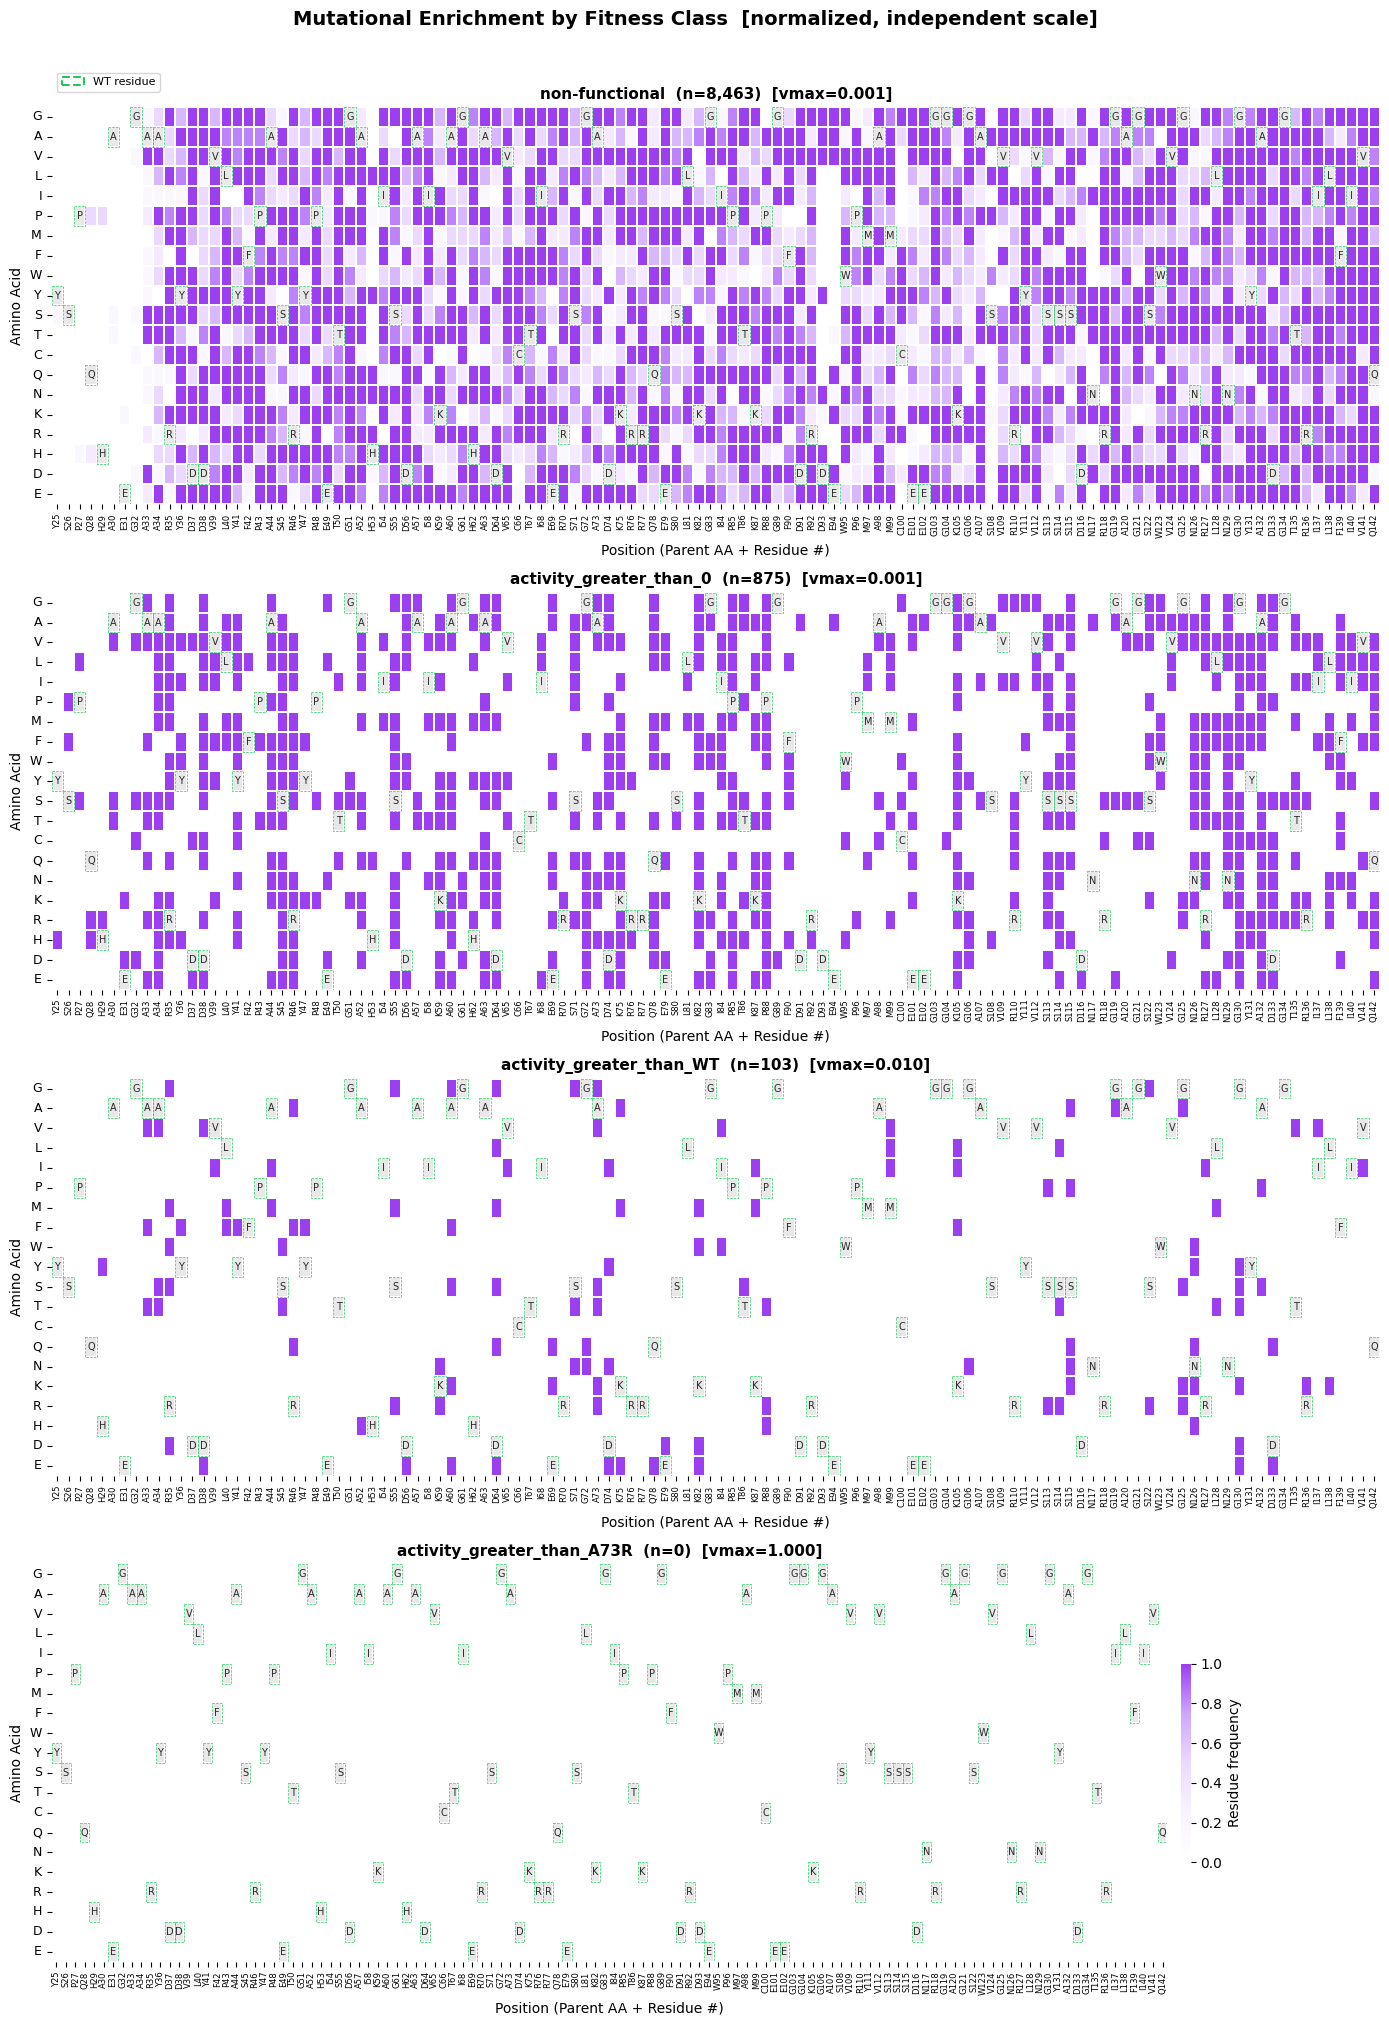

In [81]:
for generation in ['g1']:#, 'g2', 'g3', 'g4']:
    print(generation)
    df_by_generation = df[df['generations'].apply(lambda x: generation in x)]
    df_transformed = parse_mutations(
        seq_column=df_by_generation.sequence,
        reference=reference_seq,
        start_num=1,
        df=df_by_generation,
        fitness_column="activity_level",
        extra_cols=['generations'])
    
    plot_fitness_stratified_heatmap(
        df=df_transformed,
        fitness_col="activity_level",
        fitness_order=["non-functional", "activity_greater_than_0", "activity_greater_than_WT", "activity_greater_than_A73R"],
        normalize=True,
        log_scale=False,
        independent_scale=True,
        vmax_percentile=50
        )

In [62]:
for generation in ['g1']:#, 'g2', 'g3', 'g4']:
    print(generation)
    df_by_generation = df[df['generations'].apply(lambda x: generation in x)]
    df_transformed = parse_mutations(
        seq_column=df_by_generation.sequence,
        reference=reference_seq,
        start_num=1,
        df=df_by_generation,
        fitness_column="activity_level")

g1


In [63]:
df_double_mut

NameError: name 'df_double_mut' is not defined

In [64]:
df_single_mut = df[df['num_mutations'] == 1].copy()
df_double_mut = df[df['num_mutations'] == 2].copy()

df_single_mut_transformed = parse_mutations(
        seq_column=df_single_mut.sequence,
        reference=reference_seq,
        start_num=1,
        df=df_single_mut,
        fitness_column="activity_level")#.generations.value_counts()

df_double_mut_transformed = parse_mutations(
        seq_column=df_double_mut.sequence,
        reference=reference_seq,
        start_num=1,
        df=df_double_mut,
        fitness_column="activity_level")#.generations.value_counts()

plot_fitness_stratified_heatmap(
        df=df_double_mut_transformed,
        fitness_col="activity_level",
        fitness_order=["non-functional", "activity_greater_than_0", "activity_greater_than_WT", "activity_greater_than_A73R"],
        normalize=True,
        log_scale=False,
        independent_scale=True,
        vmax_percentile=99,
    #    wt_as_frequency=True
        )

NameError: name 'plot_fitness_stratified_heatmap' is not defined

Questions: better understanding of single mutants from early generations

In [65]:
for num_muts in sorted(df['num_mutations'].unique()):
    print(f"Number of mutations: {num_muts}")
    subset = df[df['num_mutations'] == num_muts]
    print(subset.activity_level.value_counts(), '\n')

Number of mutations: 0
activity_level
activity_greater_than_0    1
Name: count, dtype: int64 

Number of mutations: 1
activity_level
non-functional              1462
activity_greater_than_0      586
activity_greater_than_WT      40
Name: count, dtype: int64 

Number of mutations: 2
activity_level
non-functional                6796
activity_greater_than_0       2996
activity_greater_than_WT      1175
activity_greater_than_A73R      10
Name: count, dtype: int64 

Number of mutations: 3
activity_level
non-functional                5472
activity_greater_than_0       2302
activity_greater_than_WT      1952
activity_greater_than_A73R      34
Name: count, dtype: int64 

Number of mutations: 4
activity_level
non-functional                4567
activity_greater_than_WT      1896
activity_greater_than_0       1794
activity_greater_than_A73R      67
Name: count, dtype: int64 

Number of mutations: 5
activity_level
non-functional                3608
activity_greater_than_WT      1442
activity_great

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
import shap


# ── Constants ─────────────────────────────────────────────────────────────────

AA_ORDER = ["G", "A", "V", "L", "I", "M", "P", "F", "W", "Y", 
            "S", "T", "C", "Q", "N", "K", "R", "H", "D", "E"]

# Purple-orange diverging colormap (purple = deleterious, orange = activating)
PURP_ORANGE = LinearSegmentedColormap.from_list(
    "purp_orange",
    ["#5c1a8c", "#9b59b6", "#d8c8f0", "#ffffff", "#fddbb0", "#d4730a", "#7a3f00"],
)


def _get_pos_cols(df: pd.DataFrame) -> list:
    """Return position columns — assumes format like 'A24', 'G102', etc."""
    return [c for c in df.columns if len(c) > 1 and c[0].isalpha() and c[1:].replace("", "").isdigit()
            or (len(c) > 1 and c[0].isupper() and c[1:].isdigit())]


def _sort_positions(pos_list: list) -> list:
    """Sort position labels by their numeric component."""
    return sorted(pos_list, key=lambda x: int(''.join(filter(str.isdigit, x))))


# ── Feature engineering ───────────────────────────────────────────────────────

def build_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """
    One-hot encode per-position columns from parse_mutations output.

    Each (position, amino_acid) pair becomes a binary column e.g. 'A24_K'
    meaning 'residue K observed at position 24 (parent was A)'.
    The WT state at each position is the implicit reference (all zeros).

    Returns
    -------
    Binary DataFrame, shape (n_sequences, n_position_AA_combinations)
    """
    pos_cols = _get_pos_cols(df)
    wt_residues = {col: col[0] for col in pos_cols}

    feature_frames = []
    for col in _sort_positions(pos_cols):
        wt_aa = wt_residues[col]
        non_wt_aas = [aa for aa in df[col].unique() if aa != wt_aa]
        for aa in non_wt_aas:
            feature_name = f"{col}_{aa}"
            feature_frames.append(
                pd.Series((df[col] == aa).astype(int), name=feature_name)
            )

    if not feature_frames:
        raise ValueError("No mutation features found.")

    return pd.concat(feature_frames, axis=1).fillna(0)


# ── Enrichment analysis ───────────────────────────────────────────────────────

def compute_enrichment(
    df: pd.DataFrame,
    fitness_col: str,
    positive_class: str,
    negative_class: str,
    pseudocount: float = 0.5,
) -> pd.DataFrame:
    """
    Compute log2 enrichment ratio for each (position, AA) mutation.

    log2(freq_in_positive / freq_in_negative)

    Positive values  → mutation enriched in positive_class (activating)
    Negative values  → mutation enriched in negative_class (deleterious)

    Parameters
    ----------
    positive_class  : e.g. "activity_greater_than_A73R"
    negative_class  : e.g. "non-functional"
    pseudocount     : added to all counts before ratio to avoid log(0)
    """
    pos_cols = _get_pos_cols(df)
    wt_residues = {col: col[0] for col in pos_cols}

    pos_df = df[df[fitness_col] == positive_class]
    neg_df = df[df[fitness_col] == negative_class]

    records = []
    for col in pos_cols:
        wt_aa = wt_residues[col]
        for aa in AA_ORDER:
            if aa == wt_aa:
                continue
            pos_freq = ((pos_df[col] == aa).sum() + pseudocount) / (len(pos_df) + pseudocount)
            neg_freq = ((neg_df[col] == aa).sum() + pseudocount) / (len(neg_df) + pseudocount)
            log2_enrich = np.log2(pos_freq / neg_freq)
            records.append({
                "position":    col,
                "aa":          aa,
                "feature":     f"{col}_{aa}",
                "pos_freq":    pos_freq,
                "neg_freq":    neg_freq,
                "log2_enrich": log2_enrich,
            })

    return pd.DataFrame(records).sort_values("log2_enrich", ascending=False)


def plot_enrichment_heatmap(
    enrichment_df: pd.DataFrame,
    top_n_positions: int = None,
    figsize: tuple = (18, 7),
    vmax: float = None,
    percentile_clip: float = 95,
):
    """
    Diverging heatmap of log2 enrichment.
    Purple = deleterious, orange = activating.

    Parameters
    ----------
    top_n_positions : if set, only show the N most variable positions
                      (ranked by max absolute enrichment)
    percentile_clip : clips colormap range to this percentile of abs values
                      to avoid a few outliers dominating the color scale.
                      Set to 100 to use true max.
    """
    pos_cols_ordered = _sort_positions(enrichment_df["position"].unique().tolist())

    if top_n_positions:
        top_pos = (
            enrichment_df.groupby("position")["log2_enrich"]
            .apply(lambda x: x.abs().max())
            .nlargest(top_n_positions)
            .index.tolist()
        )
        # Preserve numeric order within the top positions
        pos_cols_ordered = [p for p in pos_cols_ordered if p in top_pos]
        enrichment_df = enrichment_df[enrichment_df["position"].isin(top_pos)]

    # Build matrix: rows = AA_ORDER, cols = positions
    mat = pd.DataFrame(np.nan, index=AA_ORDER, columns=pos_cols_ordered)
    for _, row in enrichment_df.iterrows():
        if row["aa"] in AA_ORDER and row["position"] in mat.columns:
            mat.loc[row["aa"], row["position"]] = row["log2_enrich"]

    # WT cells get 0 (neutral reference)
    wt_residues = {col: col[0] for col in pos_cols_ordered}
    for col in pos_cols_ordered:
        if wt_residues[col] in mat.index:
            mat.loc[wt_residues[col], col] = 0.0

    # Clip colormap range to percentile to avoid outlier-driven skew
    all_vals = mat.values[~np.isnan(mat.values)]
    absmax = vmax or float(np.nanpercentile(np.abs(all_vals), percentile_clip))

    norm = TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        mat,
        ax=ax,
        cmap=PURP_ORANGE,
        norm=norm,
        linewidths=0.1,
        linecolor="white",
        cbar_kws={
            "label": "log2 enrichment (orange → activating, purple → deleterious)",
            "shrink": 0.5,
        },
        mask=mat.isna(),
    )

    # Dashed box around WT cells
    for x, col in enumerate(pos_cols_ordered):
        wt_aa = wt_residues[col]
        if wt_aa in AA_ORDER:
            y = AA_ORDER.index(wt_aa)
            ax.add_patch(plt.Rectangle(
                (x, y), 1, 1, fill=False,
                edgecolor="#2d8a5e", linewidth=1.0, linestyle="--",
            ))

    ax.set_xticks(np.arange(0.5, len(pos_cols_ordered), 1))
    ax.set_xticklabels(pos_cols_ordered, rotation=90, ha="center", fontsize=6)
    ax.set_yticks(np.arange(0.5, len(AA_ORDER), 1))
    ax.set_yticklabels(AA_ORDER, rotation=0, fontsize=9)
    ax.set_title(
        "Mutation Enrichment: best variant vs non-functional\n"
        "(orange = activating, purple = deleterious)",
        fontsize=12, weight="bold",
    )
    plt.tight_layout()
    plt.show()


# ── Logistic regression ───────────────────────────────────────────────────────

def fit_logistic_model(
    df: pd.DataFrame,
    fitness_col: str,
    target_class: str,
    C: float = 1.0,
    class_weight: str = "balanced",
    cv: int = 5,
) -> tuple:
    """
    Fit a binary logistic regression: target_class vs all others.
    Returns (model, feature_matrix, cv_roc_auc scores).

    Parameters
    ----------
    target_class  : the class to predict (e.g. "activity_greater_than_A73R")
    C             : inverse regularization strength — smaller = more regularized
    class_weight  : 'balanced' recommended given class imbalance
    """
    X = build_feature_matrix(df)
    y = (df[fitness_col] == target_class).astype(int).values

    model = LogisticRegression(
        C=C,
        class_weight=class_weight,
        max_iter=1000,
        solver="lbfgs",
    )

    cv_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    print(f"CV ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

    model.fit(X, y)
    return model, X, cv_scores


def plot_logistic_coefficients(
    model: LogisticRegression,
    feature_matrix: pd.DataFrame,
    top_n: int = 30,
    figsize: tuple = (10, 8),
):
    """
    Bar chart of top positive and negative logistic regression coefficients.
    Orange = associated with target class, purple = associated with other classes.
    """
    coef_df = pd.DataFrame({
        "feature":     feature_matrix.columns,
        "coefficient": model.coef_[0],
    }).sort_values("coefficient")

    # Top N positive and negative
    plot_df = pd.concat([coef_df.head(top_n // 2), coef_df.tail(top_n // 2)])
    colors = ["#5c1a8c" if c < 0 else "#d4730a" for c in plot_df["coefficient"]]

    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(plot_df["feature"], plot_df["coefficient"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Logistic regression coefficient", fontsize=11)
    ax.set_title(
        f"Top {top_n} most predictive mutations\n"
        "(orange = activating, purple = deleterious)",
        fontsize=12, weight="bold",
    )
    plt.tight_layout()
    plt.show()

    return coef_df


def plot_coefficient_heatmap(
    coef_df: pd.DataFrame,
    figsize: tuple = (18, 7),
    vmax: float = None,
    percentile_clip: float = 95,
):
    """
    Positional heatmap colored by logistic regression coefficient.
    Orange = activating, purple = deleterious.
    """
    coef_df = coef_df.copy()
    coef_df["position"] = coef_df["feature"].str.rsplit("_", n=1).str[0]
    coef_df["aa"]       = coef_df["feature"].str.rsplit("_", n=1).str[1]

    pos_cols_ordered = _sort_positions(coef_df["position"].unique().tolist())
    wt_residues = {col: col[0] for col in pos_cols_ordered}

    mat = pd.DataFrame(np.nan, index=AA_ORDER, columns=pos_cols_ordered)
    for _, row in coef_df.iterrows():
        if row["aa"] in AA_ORDER and row["position"] in mat.columns:
            mat.loc[row["aa"], row["position"]] = row["coefficient"]

    for col in pos_cols_ordered:
        if wt_residues[col] in mat.index:
            mat.loc[wt_residues[col], col] = 0.0

    all_vals = mat.values[~np.isnan(mat.values)]
    absmax = vmax or float(np.nanpercentile(np.abs(all_vals), percentile_clip))
    norm = TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        mat, ax=ax,
        cmap=PURP_ORANGE,
        norm=norm,
        linewidths=0.1,
        linecolor="white",
        cbar_kws={"label": "Logistic regression coefficient", "shrink": 0.5},
        mask=mat.isna(),
    )

    for x, col in enumerate(pos_cols_ordered):
        wt_aa = wt_residues[col]
        if wt_aa in AA_ORDER:
            y = AA_ORDER.index(wt_aa)
            ax.add_patch(plt.Rectangle(
                (x, y), 1, 1, fill=False,
                edgecolor="#2d8a5e", linewidth=1.0, linestyle="--",
            ))

    ax.set_xticks(np.arange(0.5, len(pos_cols_ordered), 1))
    ax.set_xticklabels(pos_cols_ordered, rotation=90, ha="center", fontsize=6)
    ax.set_yticks(np.arange(0.5, len(AA_ORDER), 1))
    ax.set_yticklabels(AA_ORDER, rotation=0, fontsize=9)
    ax.set_title(
        "Logistic Regression Coefficients\n"
        "(orange = activating, purple = deleterious)",
        fontsize=12, weight="bold",
    )
    plt.tight_layout()
    plt.show()


# ── Random forest + SHAP ─────────────────────────────────────────────────────

def fit_random_forest(
    df: pd.DataFrame,
    fitness_col: str,
    target_class: str,
    n_estimators: int = 300,
    class_weight: str = "balanced",
    cv: int = 5,
) -> tuple:
    """
    Fit a binary random forest: target_class vs all others.
    Returns (model, feature_matrix, cv_roc_auc scores).
    """
    X = build_feature_matrix(df)
    y = (df[fitness_col] == target_class).astype(int).values

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        class_weight=class_weight,
        n_jobs=-1,
        random_state=42,
    )

    cv_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    print(f"CV ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

    model.fit(X, y)
    return model, X, cv_scores


def plot_shap_summary(
    model,
    feature_matrix: pd.DataFrame,
    max_display: int = 30,
    sample_n: int = 2000,
):
    """
    SHAP beeswarm plot — shows which mutations push predictions toward
    or away from the target class, and by how much, for each sequence.

    Parameters
    ----------
    sample_n : subsample for speed — SHAP on full dataset can be slow
    """
    X_sample = feature_matrix.sample(
        min(sample_n, len(feature_matrix)), random_state=42
    )
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    # For binary RF, shap_values is a list [class0, class1] — take class1
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    shap.summary_plot(
        sv, X_sample,
        max_display=max_display,
        show=True,
        plot_type="dot",
    )


# ── Mutation number analysis ──────────────────────────────────────────────────

def plot_activity_by_mutation_count(
    df: pd.DataFrame,
    fitness_col: str,
    fitness_order: list = None,
    figsize: tuple = (12, 5),
):
    """
    Stacked bar chart showing class composition at each mutation count.
    Reveals whether more mutations generally help or hurt.
    Uses sequential purple palette with orange for top activity class.
    """
    pos_cols = _get_pos_cols(df)
    wt_residues = {col: col[0] for col in pos_cols}

    df = df.copy()
    df["n_mutations"] = df[pos_cols].apply(
        lambda row: sum(row[col] != wt_residues[col] for col in pos_cols), axis=1
    )

    if fitness_order is None:
        fitness_order = df[fitness_col].value_counts().index.tolist()

    counts = (
        df.groupby(["n_mutations", fitness_col])
        .size()
        .unstack(fill_value=0)
        [fitness_order]
    )
    props = counts.div(counts.sum(axis=1), axis=0)

    # Sequential purple → orange for top class
    colors = ["#e8e0f0", "#dcc3fa", "#a675fa", "#fb8c15"][:len(fitness_order)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    counts.plot(kind="bar", stacked=True, ax=ax1, color=colors, width=0.8)
    ax1.set_xlabel("Number of mutations")
    ax1.set_ylabel("Count")
    ax1.set_title("Sequence counts by mutation number", weight="bold")
    ax1.legend(loc="upper right", fontsize=7)
    ax1.tick_params(axis="x", rotation=0)

    props.plot(kind="bar", stacked=True, ax=ax2, color=colors, width=0.8)
    ax2.set_xlabel("Number of mutations")
    ax2.set_ylabel("Proportion")
    ax2.set_title("Activity class proportion by mutation number", weight="bold")
    ax2.legend(loc="upper right", fontsize=7)
    ax2.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()

    return counts, props


# ── Suggested workflow ────────────────────────────────────────────────────────

"""
Recommended order for your dataset:

1. Mutation count landscape
   plot_activity_by_mutation_count(df_transformed, fitness_col="activity_level",
       fitness_order=["non-functional", "activity_greater_than_0",
                      "activity_greater_than_WT", "activity_greater_than_A73R"])

2. Enrichment heatmap (no model, fast sanity check)
   enrich = compute_enrichment(df_transformed, fitness_col="activity_level",
       positive_class="activity_greater_than_A73R",
       negative_class="non-functional")
   plot_enrichment_heatmap(enrich, top_n_positions=40)

3. Logistic regression (interpretable linear model)
   model_lr, X, cv = fit_logistic_model(df_transformed, fitness_col="activity_level",
       target_class="activity_greater_than_A73R")
   coef_df = plot_logistic_coefficients(model_lr, X, top_n=40)
   plot_coefficient_heatmap(coef_df)

4. Random forest + SHAP (captures epistasis, slower)
   model_rf, X, cv = fit_random_forest(df_transformed, fitness_col="activity_level",
       target_class="activity_greater_than_A73R")
   plot_shap_summary(model_rf, X)
"""

# ── Run ───────────────────────────────────────────────────────────────────────

plot_activity_by_mutation_count(
    df_transformed,
    fitness_col="activity_level",
    fitness_order=[
        "non-functional",
        "activity_greater_than_0",
        "activity_greater_than_WT",
        "activity_greater_than_A73R",
    ],
)

enrich = compute_enrichment(
    df_transformed,
    fitness_col="activity_level",
    positive_class="activity_greater_than_A73R",
    negative_class="non-functional",
)
plot_enrichment_heatmap(enrich, top_n_positions=40)

/Users/zari/Documents/github/nuclease_design_cloned_repo/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyError: "['activity_greater_than_A73R'] not in index"

In [67]:
df_single_mut_transformed

,sequence,activity_level,mutation_string,mutated_residues,mutated_positions,Y25,S26,P27,Q28,H29,...,D133,G134,T135,R136,I137,L138,F139,I140,V141,Q142
0,MIKKWAVHLLFSALVLLGLSGGAAYSPQHSEGAARYDDVLYFPASR...,activity_greater_than_0,S,S,30,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
1,MIKKWAVHLLFSALVLLGLSGGAAYSPQHTEGAARYDDVLYFPASR...,activity_greater_than_0,T,T,30,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
2,MIKKWAVHLLFSALVLLGLSGGAAYSPQHVEGAARYDDVLYFPASR...,activity_greater_than_0,V,V,30,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
3,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGCARYDDVLYFPASR...,non-functional,C,C,33,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
4,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGDARYDDVLYFPASR...,non-functional,D,D,33,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2083,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,R,R,131,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
2084,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,S,S,131,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
2085,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,T,T,131,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q
2086,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,activity_greater_than_0,V,V,131,Y,S,P,Q,H,...,D,G,T,R,I,L,F,I,V,Q


CV ROC-AUC: 0.500 ± 0.000


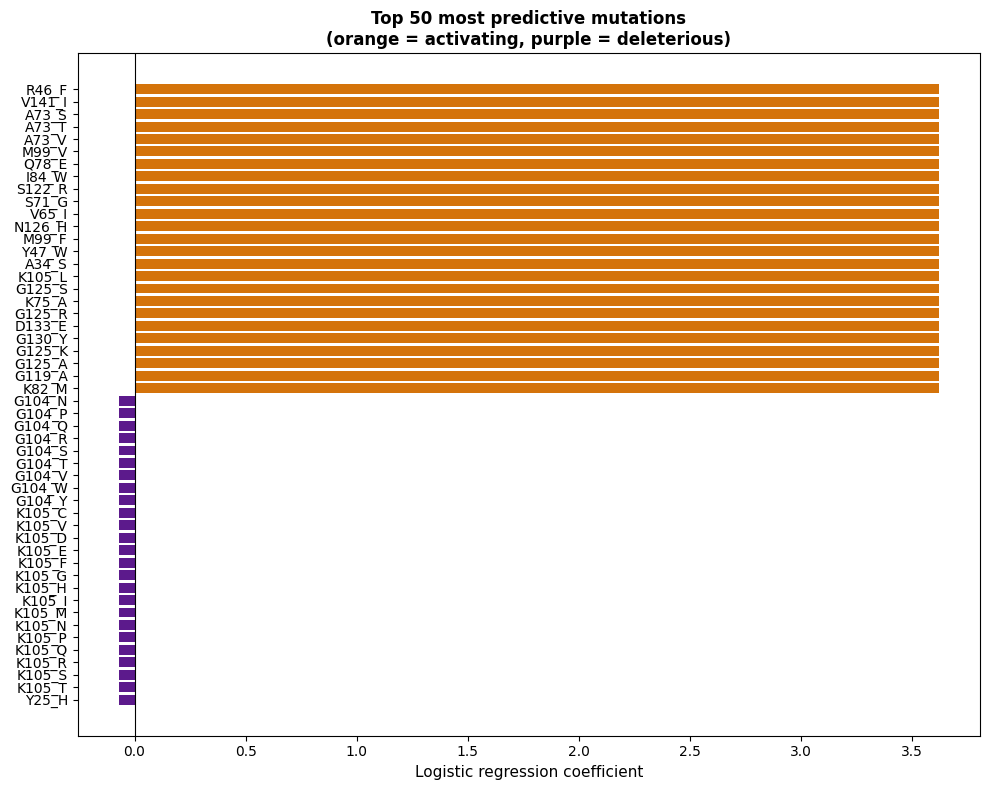

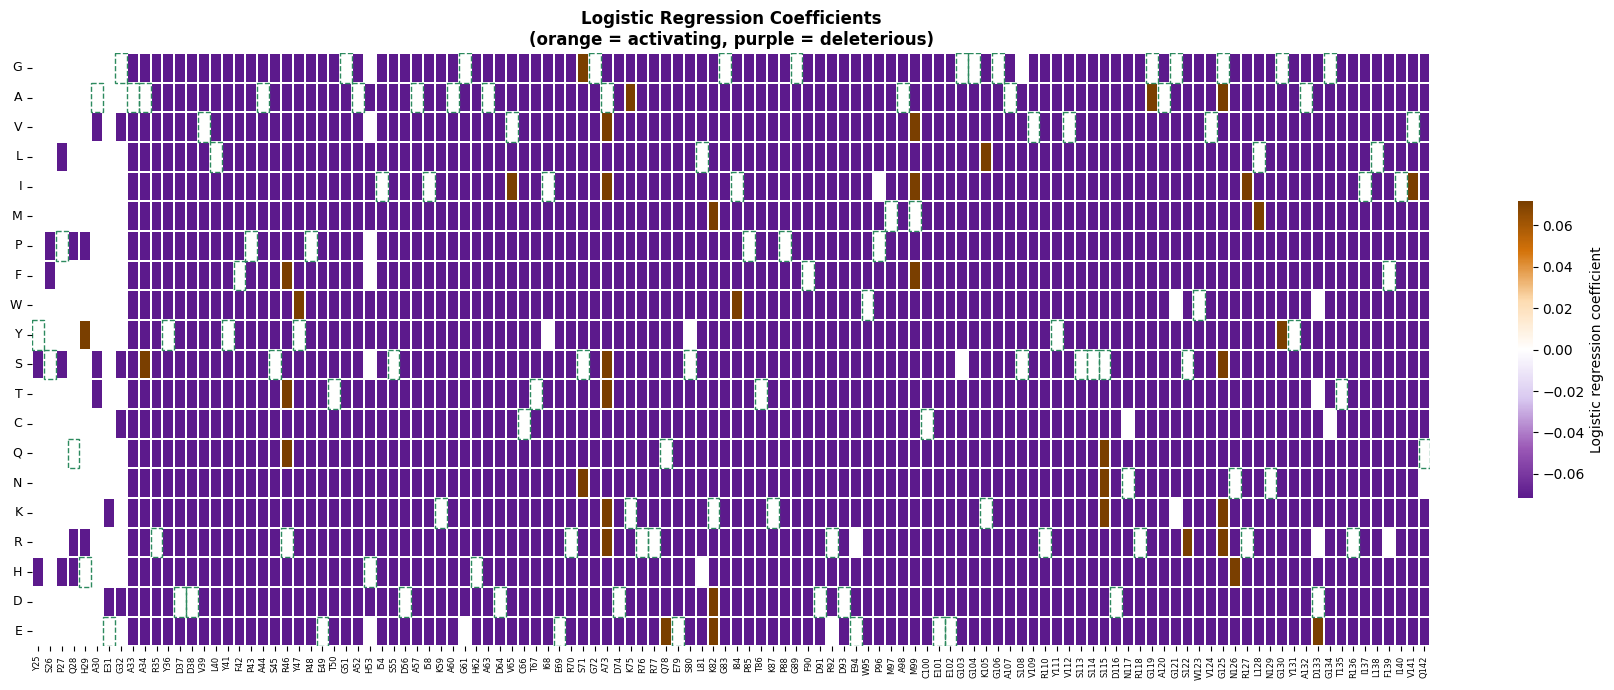

In [68]:
df_single_mut_transformed
model_slr, X, cv = fit_logistic_model(df_single_mut_transformed, fitness_col="activity_level",
       target_class="activity_greater_than_WT")
coef_df = plot_logistic_coefficients(model_slr, X, top_n=50)
plot_coefficient_heatmap(coef_df)

In [69]:
model_lr, X, cv = fit_logistic_model(df_transformed, fitness_col="activity_level",
       target_class="activity_greater_than_A73R")
coef_df = plot_logistic_coefficients(model_lr, X, top_n=50)
plot_coefficient_heatmap(coef_df)

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/zari/Documents/github/nuclease_design_cloned_repo/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/zari/Documents/github/nuclease_design_cloned_repo/.venv/lib/python3.11/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/zari/Documents/github/nuclease_design_cloned_repo/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py", line 1335, in fit
    raise ValueError(
ValueError: Th

In [ ]:
#Random forest + SHAP (captures epistasis, slower)
model_rf, X, cv = fit_random_forest(df_transformed, fitness_col="activity_level",
       target_class="activity_greater_than_A73R")
plot_shap_summary(model_rf, X)

CV ROC-AUC: 0.650 ± 0.063


In [70]:
df_g1 = df[df['generations'].apply(lambda x: 'g1' in x)].copy()
df_g2 = df[df['generations'].apply(lambda x: 'g2' in x)].copy()
df_g2#.activity_level.value_counts()

,mutations,sublibrary_names,generations,activity_greater_than_neg_control,activity_greater_than_wt,activity_greater_than_a73r,num_mutations,sequence,activity_level,is_functional
0,(),"(g4_mbo_seeds, g4_wt_synonyms, g3_wt_synonyms,...","(g1, g2, g3, g4)",True,False,False,0,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,activity_greater_than_0,True
3,"((A, 30, T),)","(g2_unmatched, g1_eppcr)","(g1, g2)",True,False,None,1,MIKKWAVHLLFSALVLLGLSGGAAYSPQHTEGAARYDDVLYFPASR...,activity_greater_than_0,True
2848,"((A, 33, S),)","(g3_single_mutants, g2_unmatched, g1_eppcr)","(g1, g2, g3)",True,False,False,1,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGSARYDDVLYFPASR...,activity_greater_than_0,True
2889,"((A, 33, T),)","(g3_single_mutants, g2_unmatched, g1_eppcr)","(g1, g2, g3)",True,False,False,1,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGTARYDDVLYFPASR...,activity_greater_than_0,True
3488,"((A, 33, V), (A, 52, S), (A, 73, Q), (E, 79, Y...","(g2_unmatched,)","(g2,)",False,False,None,6,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGVARYDDVLYFPASR...,non-functional,False
...,...,...,...,...,...,...,...,...,...,...
55726,"((Y, 111, S),)","(g2_single_mutants, g1_eppcr)","(g1, g2)",False,False,None,1,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,False
55727,"((Y, 111, T),)","(g2_single_mutants, g1_eppcr)","(g1, g2)",False,False,None,1,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,False
55728,"((Y, 111, V),)","(g2_single_mutants,)","(g2,)",False,False,None,1,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,False
55729,"((Y, 111, W),)","(g2_single_mutants, g1_eppcr)","(g1, g2)",False,False,None,1,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,False


In [71]:
df_transformed_g2.activity_level.value_counts()

NameError: name 'df_transformed_g2' is not defined

In [104]:
df_transformed=parse_mutations(seq_column=df.sequence, reference=reference_seq, start_num=1, df=df, fitness_column="activity_level")
df_transformed_g1=parse_mutations(seq_column=df_g1.sequence, reference=reference_seq, start_num=1, df=df_g1, fitness_column="activity_level", extra_cols=["generations", "sublibrary_names"], full_length=True)
df_transformed_g2=parse_mutations(seq_column=df_g2.sequence, reference=reference_seq, start_num=1, df=df_g2, fitness_column="activity_level", extra_cols=["generations", "sublibrary_names"], full_length=True)
df_transformed_g2

,sequence,activity_level,generations,sublibrary_names,mutation_string,mutated_residues,mutated_positions,M1,I2,K3,...,D133,G134,T135,R136,I137,L138,F139,I140,V141,Q142
0,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,activity_greater_than_0,"(g1, g2, g3, g4)","(g4_mbo_seeds, g4_wt_synonyms, g3_wt_synonyms,...",,,,M,I,K,...,D,G,T,R,I,L,F,I,V,Q
1,MIKKWAVHLLFSALVLLGLSGGAAYSPQHTEGAARYDDVLYFPASR...,activity_greater_than_0,"(g1, g2)","(g2_unmatched, g1_eppcr)",T,T,30,M,I,K,...,D,G,T,R,I,L,F,I,V,Q
2,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGSARYDDVLYFPASR...,activity_greater_than_0,"(g1, g2, g3)","(g3_single_mutants, g2_unmatched, g1_eppcr)",S,S,33,M,I,K,...,D,G,T,R,I,L,F,I,V,Q
3,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGTARYDDVLYFPASR...,activity_greater_than_0,"(g1, g2, g3)","(g3_single_mutants, g2_unmatched, g1_eppcr)",T,T,33,M,I,K,...,D,G,T,R,I,L,F,I,V,Q
4,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGVARYDDVLYFPASR...,non-functional,"(g2,)","(g2_unmatched,)",VSQYPT,"V,S,Q,Y,P,T","33,52,73,79,82,106",M,I,K,...,D,G,T,R,I,L,F,I,V,Q
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14673,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,"(g1, g2)","(g2_single_mutants, g1_eppcr)",S,S,111,M,I,K,...,D,G,T,R,I,L,F,I,V,Q
14674,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,"(g1, g2)","(g2_single_mutants, g1_eppcr)",T,T,111,M,I,K,...,D,G,T,R,I,L,F,I,V,Q
14675,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,"(g2,)","(g2_single_mutants,)",V,V,111,M,I,K,...,D,G,T,R,I,L,F,I,V,Q
14676,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,"(g1, g2)","(g2_single_mutants, g1_eppcr)",W,W,111,M,I,K,...,D,G,T,R,I,L,F,I,V,Q


In [80]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


# ── Amino acid ordering + grouping ───────────────────────────────────────────

AA_ORDER = [
    "G", "A", "V", "L", "I", "P", "M",   # Nonpolar aliphatic
    "F", "W", "Y",                         # Aromatic
    "S", "T", "C", "Q", "N",              # Polar uncharged
    "K", "R", "H",                         # Positively charged
    "D", "E",                              # Negatively charged
]

AA_GROUP_LABELS = {
    "Nonpolar\naliphatic": ["G", "A", "V", "L", "I", "P", "M"],
    "Aromatic":            ["F", "W", "Y"],
    "Polar\nuncharged":    ["S", "T", "C", "Q", "N"],
    "Positive":            ["K", "R", "H"],
    "Negative":            ["D", "E"],
}

VIOLET_CMAP = LinearSegmentedColormap.from_list(
    "violet_scale",
    ["#ffffff", "#f9f3ff", "#ecd9ff", "#cfa6ff", "#9B3FF1"]
)


# ── Legend handler for Rectangle patches ─────────────────────────────────────

class _RectHandler(HandlerBase):
    def create_artists(self, legend, orig_handle, x0, y0, width, height, fontsize, trans):
        r = Rectangle(
            (x0, y0), width, height,
            fill=False, edgecolor="#22c55e", lw=1.5, linestyle="--", transform=trans
        )
        return [r]


# ── parse_mutations ───────────────────────────────────────────────────────────

def parse_mutations(
    seq_column: pd.Series,
    reference: str,
    start_num: int = 1,
    df: pd.DataFrame = None,
    fitness_column: str = "activity_level",
    extra_cols: list = None,
    full_length: bool = False,
) -> pd.DataFrame:
    """
    Compare protein sequences against a reference and extract mutation information.

    Parameters
    ----------
    seq_column   : pd.Series of protein sequences (all must be same length as reference)
    reference    : reference/parent protein sequence string
    start_num    : residue number assigned to the first position (default: 1)
    df           : original dataframe — if provided, 'activity_level' is carried over
                   automatically; use extra_cols to pull additional columns too
    fitness_column : name of the fitness/activity column to carry over (default: 'activity_level')
    extra_cols   : additional column names from df to carry over (e.g. ["batch", "round"])
    full_length  : if True, output a column for every position in the protein (not just
                   mutated positions). WT positions will show the reference amino acid.
                   If False (default), only positions mutated in at least one sequence
                   are included as columns.
    """
    ref       = reference.upper()
    sequences = seq_column.str.upper().reset_index(drop=True)

    # Columns to carry over from the original dataframe
    carry = []
    if df is not None:
        if fitness_column in df.columns:
            carry.append(fitness_column)
        if extra_cols:
            carry += [c for c in extra_cols if c in df.columns and c not in carry]

    carry_data = {}
    if df is not None and carry:
        for col in carry:
            carry_data[col] = df[col].reset_index(drop=True)

    # Validate sequence lengths
    for seq in sequences:
        if len(seq) != len(ref):
            raise ValueError(
                f"Sequence length {len(seq)} does not match reference length {len(ref)}."
            )

    if full_length:
        # All positions in the protein
        positions_to_output = list(range(len(ref)))
    else:
        # Only positions mutated in at least one sequence
        all_mut_positions = set()
        for seq in sequences:
            for i, (ref_aa, seq_aa) in enumerate(zip(ref, seq)):
                if seq_aa != ref_aa:
                    all_mut_positions.add(i)
        positions_to_output = sorted(all_mut_positions)

    col_names = {i: f"{ref[i]}{i + start_num}" for i in positions_to_output}

    # Still need mutated positions for mutation_string etc. regardless of output mode
    if full_length:
        all_mut_positions = set()
        for seq in sequences:
            for i, (ref_aa, seq_aa) in enumerate(zip(ref, seq)):
                if seq_aa != ref_aa:
                    all_mut_positions.add(i)
        sorted_mut_positions = sorted(all_mut_positions)
    else:
        sorted_mut_positions = positions_to_output

    records = []
    for idx, seq in enumerate(sequences):
        mut_residues  = []
        mut_positions = []
        for i in sorted_mut_positions:
            if seq[i] != ref[i]:
                mut_residues.append(seq[i])
                mut_positions.append(str(i + start_num))

        record = {"sequence": seq}

        # Carried-over columns inserted right after sequence for readability
        for col in carry:
            record[col] = carry_data[col][idx]

        record.update({
            "mutation_string":   "".join(mut_residues),
            "mutated_residues":  ",".join(mut_residues),
            "mutated_positions": ",".join(mut_positions),
        })

        # Position columns — all positions if full_length, else only mutated positions
        for i in positions_to_output:
            record[col_names[i]] = seq[i]

        records.append(record)

    return pd.DataFrame(records)

# ── Shared helpers ────────────────────────────────────────────────────────────

def _get_pos_cols(df: pd.DataFrame) -> list:
    return [c for c in df.columns if len(c) >= 2 and c[0].isalpha() and c[1:].isdigit()]


def _build_count_matrix(subset: pd.DataFrame, pos_cols: list) -> pd.DataFrame:
    mat = pd.DataFrame(0.0, index=AA_ORDER, columns=pos_cols)
    for col in pos_cols:
        counts = subset[col].value_counts()
        for aa, cnt in counts.items():
            if aa in mat.index:
                mat.loc[aa, col] = cnt
    return mat


def _split_wt_mut(mat: pd.DataFrame, wt_residues: dict) -> tuple:
    wt_mat  = mat.copy()
    mut_mat = mat.copy()
    for col in mat.columns:
        wt_aa = wt_residues[col]
        for aa in AA_ORDER:
            if aa == wt_aa:
                mut_mat.loc[aa, col] = np.nan
            else:
                wt_mat.loc[aa, col] = np.nan
                # Treat zero-count non-WT residues as NaN so they
                # are masked rather than colored by emphasize_mutations
                if mut_mat.loc[aa, col] == 0:
                    mut_mat.loc[aa, col] = np.nan
    return wt_mat, mut_mat


def _compute_vmax(matrices: dict, wt_residues: dict, log_scale: bool,
                  vmax_percentile: float) -> float:
    all_vals = []
    for mat in matrices.values():
        _, mut_mat = _split_wt_mut(mat, wt_residues)
        vals = np.log1p(mut_mat.values) if log_scale else mut_mat.values
        flat = vals[~np.isnan(vals)]   # keep zeros — exclude only WT (NaN)
        if len(flat):
            all_vals.append(flat)
    if not all_vals:
        return 1.0
    return float(np.percentile(np.concatenate(all_vals), vmax_percentile))



def _draw_panel(ax, wt_mat, mut_mat, pos_cols, wt_residues, vmax,
                show_cbar, cbar_label, log_scale, show_ylabel, title,
                emphasize_mutations: bool = False):
    """
    Draw a single heatmap panel onto ax.

    Parameters
    ----------
    emphasize_mutations : if True, zero-count mutation cells are rendered in a
                          very light violet tint instead of white, making every
                          position that was *tested* (present in the dataset but
                          not observed as a mutation) visually distinct from the
                          WT cell. Cells with actual counts still use the full
                          violet colormap.
    """
    display_mut = np.log1p(mut_mat) if log_scale else mut_mat

    # ── Layer 1: WT cells — grey with AA label ───────────────────────────────
    # Build annotation matrix: show the WT residue letter in each WT cell
    wt_annot = wt_mat.copy().astype(object)
    for col in pos_cols:
        wt_aa = wt_residues[col]
        for aa in AA_ORDER:
            if aa == wt_aa:
                wt_annot.loc[aa, col] = wt_aa
            else:
                wt_annot.loc[aa, col] = ""

    sns.heatmap(
        wt_mat,
        ax=ax,
        cmap=["#e8e8e8"],
        linewidths=0.1,
        linecolor="white",
        cbar=False,
        annot=wt_annot,
        fmt="",
        annot_kws={"size": 7, "weight": "normal"},#, "color": "#969494", "weight": "normal"},
        mask=wt_mat.isna(),
    )

    # ── Layer 2 (optional): tested-but-zero mutation cells — faint tint ──────
    if emphasize_mutations:
        # Cells that are in mut_mat but have value 0 (tested, not observed)
        zero_mut = mut_mat.copy()
        zero_mut[zero_mut != 0] = np.nan   # keep only zeros
        zero_mut[zero_mut.isna() & ~mut_mat.isna()] = np.nan

        # Re-derive: mut_mat is NaN for WT positions, 0 or >0 for non-WT
        tested_zero = mut_mat.copy()
        tested_zero[tested_zero > 0] = np.nan   # hide cells with actual counts

        sns.heatmap(
            tested_zero,
            ax=ax,
            cmap=["#f3eeff"],          # very faint violet tint
            linewidths=0.1,
            linecolor="white",
            cbar=False,
            mask=tested_zero.isna(),
        )

    # ── Layer 3: mutation cells — full violet colormap ───────────────────────
    sns.heatmap(
        display_mut,
        ax=ax,
        cmap=VIOLET_CMAP,
        vmin=0,
        vmax=vmax,
        linewidths=0.1,
        linecolor="white",
        cbar=show_cbar,
        cbar_kws={"label": cbar_label, "shrink": 0.5, "pad": 0.01} if show_cbar else None,
        mask=mut_mat.isna() | (mut_mat == 0),  # skip zero-count cells
    )

    # ── Green dashed WT boxes ─────────────────────────────────────────────────
    for x, col in enumerate(pos_cols):
        wt_aa = wt_residues[col]
        if wt_aa in AA_ORDER:
            y = AA_ORDER.index(wt_aa)
            ax.add_patch(Rectangle(
                (x, y), 1, 1,
                fill=False, edgecolor="#22c55e",
                linewidth=0.5, linestyle="--",
            ))

    # ── Physicochemical group dividers ────────────────────────────────────────
  #  cumulative = 0
  #  for group, members in AA_GROUP_LABELS.items():
  #      cumulative += len(members)
  #      if cumulative < len(AA_ORDER):
  #          ax.axhline(cumulative, color="black", linewidth=1.0,
  #                     linestyle="--", alpha=0.3)

    # ── Axis ticks — x always shown, y always shown ───────────────────────────
    ax.set_xticks(np.arange(0.5, len(pos_cols), 1))
    ax.set_xticklabels(pos_cols, rotation=90, ha="center", fontsize=6)
    ax.set_xlabel("Position (Parent AA + Residue #)", fontsize=10)

    ax.set_yticks(np.arange(0.5, len(AA_ORDER), 1))
    ax.set_yticklabels(AA_ORDER, rotation=0, fontsize=9)
    ax.set_ylabel("Amino Acid" if show_ylabel else "", fontsize=10)

    ax.set_title(title, fontsize=11, weight="bold", pad=6)

  #  # ── Physicochemical group labels on right ─────────────────────────────────
  #  right_ax = ax.twinx()
  #  right_ax.set_ylim(ax.get_ylim())
  #  right_ax.set_yticks([])
  #  cumulative = 0
  #  for group, members in AA_GROUP_LABELS.items():
  #      midpoint = cumulative + len(members) / 2
  #      right_ax.text(
  #          1.01, midpoint / len(AA_ORDER), group,
  #          transform=right_ax.transAxes,
  #          va="center", ha="left", fontsize=7, color="dimgrey",
  #      )
  #      cumulative += len(members)


# ── plot_mutation_frequency_heatmap ──────────────────────────────────────────

def plot_mutation_frequency_heatmap(
    df: pd.DataFrame,
    figsize: tuple = (16, 8),
    log_scale: bool = False,
    vmax: float = None,
    vmax_percentile: float = 100,
    normalize: bool = False,
    emphasize_mutations: bool = False,
    position_range: tuple = None,
):
    """
    Single heatmap of amino acid frequency at each hotspot position.

    Parameters
    ----------
    df                  : output of parse_mutations()
    figsize             : figure size in inches
    log_scale           : apply log1p before plotting
    vmax                : manual ceiling for color scale; overrides vmax_percentile if set
    vmax_percentile     : percentile of non-zero mutation values as color ceiling
                          (100 = absolute max; try 90 to boost contrast)
    normalize           : divide counts by total sequences → frequencies
    emphasize_mutations : highlight tested-but-not-observed positions in faint violet
                          so the full mutation landscape is visible even at low counts
    position_range      : optional (start, end) tuple of residue numbers to plot,
                          inclusive on both ends. Uses the same numbering as your
                          sequence positions (e.g. start_num in parse_mutations).
                          Example: position_range=(23, 100) plots positions 23 to 100.
                          If None (default), all positions are plotted.
    """
    pos_cols = _get_pos_cols(df)
    if not pos_cols:
        print("No mutation columns found.")
        return

    # Filter to requested position range if provided
    if position_range is not None:
        start_pos, end_pos = position_range
        pos_cols = [
            col for col in pos_cols
            if start_pos <= int(''.join(filter(str.isdigit, col))) <= end_pos
        ]
        if not pos_cols:
            print(f"No mutation columns found in range {start_pos}–{end_pos}.")
            return

    wt_residues = {col: col[0] for col in pos_cols}
    mat = _build_count_matrix(df, pos_cols)
    if normalize:
        mat = mat / len(df)

    wt_mat, mut_mat = _split_wt_mut(mat, wt_residues)

    if vmax is None:
        vmax = _compute_vmax({"all": mat}, wt_residues, log_scale, vmax_percentile)

    cbar_label = (
        ("log(1 + frequency)" if normalize else "log(1 + count)")
        if log_scale else
        ("Residue frequency" if normalize else "Count")
    )

    # Build title — include range info if filtering
    range_str = f"  [positions {position_range[0]}–{position_range[1]}]" if position_range else ""
    title = (
        f"Amino Acid Frequency at Hotspot Positions  ({len(df):,} sequences)"
        + range_str
        + ("  [log scale]" if log_scale else "")
        + (f"  [vmax p{vmax_percentile}]" if vmax_percentile < 100 else "")
    )

    fig, ax = plt.subplots(figsize=figsize)

    _draw_panel(
        ax=ax,
        wt_mat=wt_mat,
        mut_mat=mut_mat,
        pos_cols=pos_cols,
        wt_residues=wt_residues,
        vmax=vmax,
        show_cbar=True,
        cbar_label=cbar_label,
        log_scale=log_scale,
        show_ylabel=True,
        title=title,
        emphasize_mutations=emphasize_mutations,
    )

    # Legend
    legend_elements = [
        Rectangle((0, 0), 1, 1, fill=False, edgecolor="#22c55e",
                  linewidth=1.5, linestyle="--"),
    ]
    legend_labels = ["WT residue"]
    if emphasize_mutations:
        legend_elements.append(Rectangle((0, 0), 1, 1, facecolor="#f3eeff",
                                         edgecolor="none"))
        legend_labels.append("Tested, not observed")

    ax.legend(
        legend_elements, legend_labels,
        handler_map={Rectangle: _RectHandler()},
        loc="upper left", bbox_to_anchor=(0, 1.06), fontsize=8,
    )

    plt.tight_layout()
    plt.show()




# ── plot_fitness_stratified_heatmap ──────────────────────────────────────────

def plot_fitness_stratified_heatmap(
    df: pd.DataFrame,
    fitness_col: str,
    fitness_order: list = None,
    figsize_per_panel: tuple = (14, 5),
    log_scale: bool = False,
    vmax: float = None,
    vmax_percentile: float = 100,
    normalize: bool = True,
    independent_scale: bool = False,
    emphasize_mutations: bool = False,
):
    """
    Vertically stacked heatmap panels, one per fitness category.

    Parameters
    ----------
    df                  : output of parse_mutations(), must also contain fitness_col
    fitness_col         : column name containing fitness category labels
    fitness_order       : order of panels top-to-bottom (defaults to value_counts order)
    figsize_per_panel   : (width, height) of each individual panel
    log_scale           : apply log1p before plotting
    vmax                : manual shared color ceiling; overrides vmax_percentile if set
    vmax_percentile     : percentile of non-zero mutation values as shared ceiling
                          (100 = absolute max; try 90–95 to boost contrast)
    normalize           : divide counts by population size → frequencies (recommended)
    independent_scale   : each panel gets its own vmax — maximizes within-panel
                          contrast but panels are no longer directly comparable
    emphasize_mutations : highlight tested-but-not-observed positions in faint violet
                          so the full mutation landscape is visible even at low counts
    """
    pos_cols = _get_pos_cols(df)
    if not pos_cols:
        print("No mutation columns found.")
        return

    if fitness_order is None:
        fitness_order = df[fitness_col].value_counts().index.tolist()

    n_panels    = len(fitness_order)
    wt_residues = {col: col[0] for col in pos_cols}

    # Build all matrices up front
    matrices = {}
    for label in fitness_order:
        subset = df[df[fitness_col] == label]
        mat = _build_count_matrix(subset, pos_cols)
        if normalize and len(subset) > 0:
            mat = mat / len(subset)
        matrices[label] = mat

    # Shared vmax
    if not independent_scale and vmax is None:
        vmax = _compute_vmax(matrices, wt_residues, log_scale, vmax_percentile)

    cbar_label = (
        ("log(1 + frequency)" if normalize else "log(1 + count)")
        if log_scale else
        ("Residue frequency" if normalize else "Count")
    )

    fig, axes = plt.subplots(
        n_panels, 1,
        figsize=(figsize_per_panel[0], figsize_per_panel[1] * n_panels),
        sharex=False,   # each panel manages its own x ticks
    )
    if n_panels == 1:
        axes = [axes]

    for idx, (ax, label) in enumerate(zip(axes, fitness_order)):
        subset  = df[df[fitness_col] == label]
        mat     = matrices[label]
        wt_mat, mut_mat = _split_wt_mut(mat, wt_residues)

        is_last = (idx == n_panels - 1)

        panel_vmax = (
            _compute_vmax({label: mat}, wt_residues, log_scale, vmax_percentile)
            if independent_scale else vmax
        )

        _draw_panel(
            ax=ax,
            wt_mat=wt_mat,
            mut_mat=mut_mat,
            pos_cols=pos_cols,
            wt_residues=wt_residues,
            vmax=panel_vmax,
            show_cbar=is_last,
            cbar_label=cbar_label,
            log_scale=log_scale,
            show_ylabel=True,
            title=f"{label}  (n={len(subset):,})"
                  + (f"  [vmax={panel_vmax:.3f}]" if independent_scale else ""),
            emphasize_mutations=emphasize_mutations,
        )

    # Legend on top panel
    legend_elements = [
        Rectangle((0, 0), 1, 1, fill=False, edgecolor="#22c55e",
                  linewidth=1.5, linestyle="--"),
    ]
    legend_labels = ["WT residue"]
    if emphasize_mutations:
        legend_elements.append(Rectangle((0, 0), 1, 1, facecolor="#f3eeff",
                                         edgecolor="none"))
        legend_labels.append("Tested, not observed")

    axes[0].legend(
        legend_elements, legend_labels,
        handler_map={Rectangle: _RectHandler()},
        loc="upper left", bbox_to_anchor=(0, 1.10), fontsize=8,
    )

    scale_notes = []
    if normalize:               scale_notes.append("normalized")
    if log_scale:               scale_notes.append("log scale")
    if independent_scale:       scale_notes.append("independent scale")
    elif vmax_percentile < 100: scale_notes.append(f"vmax p{vmax_percentile}")
    if emphasize_mutations:     scale_notes.append("mutations emphasized")

    fig.suptitle(
        "Mutational Enrichment by Fitness Class"
        + (f"  [{', '.join(scale_notes)}]" if scale_notes else ""),
        fontsize=14, weight="bold", y=1.01,
    )

    plt.tight_layout()
    plt.show()

In [72]:
plot_mutation_frequency_heatmap(df=df_double_mut_transformed, vmax=50, figsize=(16,5))

NameError: name 'plot_mutation_frequency_heatmap' is not defined

In [108]:
df_transformed_g2

,sequence,activity_level,generations,sublibrary_names,mutation_string,mutated_residues,mutated_positions,M1,I2,K3,...,D133,G134,T135,R136,I137,L138,F139,I140,V141,Q142
0,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,activity_greater_than_0,"(g1, g2, g3, g4)","(g4_mbo_seeds, g4_wt_synonyms, g3_wt_synonyms,...",,,,M,I,K,...,D,G,T,R,I,L,F,I,V,Q
1,MIKKWAVHLLFSALVLLGLSGGAAYSPQHTEGAARYDDVLYFPASR...,activity_greater_than_0,"(g1, g2)","(g2_unmatched, g1_eppcr)",T,T,30,M,I,K,...,D,G,T,R,I,L,F,I,V,Q
2,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGSARYDDVLYFPASR...,activity_greater_than_0,"(g1, g2, g3)","(g3_single_mutants, g2_unmatched, g1_eppcr)",S,S,33,M,I,K,...,D,G,T,R,I,L,F,I,V,Q
3,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGTARYDDVLYFPASR...,activity_greater_than_0,"(g1, g2, g3)","(g3_single_mutants, g2_unmatched, g1_eppcr)",T,T,33,M,I,K,...,D,G,T,R,I,L,F,I,V,Q
4,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGVARYDDVLYFPASR...,non-functional,"(g2,)","(g2_unmatched,)",VSQYPT,"V,S,Q,Y,P,T","33,52,73,79,82,106",M,I,K,...,D,G,T,R,I,L,F,I,V,Q
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14673,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,"(g1, g2)","(g2_single_mutants, g1_eppcr)",S,S,111,M,I,K,...,D,G,T,R,I,L,F,I,V,Q
14674,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,"(g1, g2)","(g2_single_mutants, g1_eppcr)",T,T,111,M,I,K,...,D,G,T,R,I,L,F,I,V,Q
14675,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,"(g2,)","(g2_single_mutants,)",V,V,111,M,I,K,...,D,G,T,R,I,L,F,I,V,Q
14676,MIKKWAVHLLFSALVLLGLSGGAAYSPQHAEGAARYDDVLYFPASR...,non-functional,"(g1, g2)","(g2_single_mutants, g1_eppcr)",W,W,111,M,I,K,...,D,G,T,R,I,L,F,I,V,Q


In [73]:
temp = df_transformed_g2[df_transformed_g2.sublibrary_names.apply(lambda x: 'g2_unmatched' in x)]#.mutated_positions.str.len().value_counts()
# 1. Mutation count landscape
plot_activity_by_mutation_count(temp, fitness_col="activity_level",
    fitness_order=["non-functional", "activity_greater_than_0",
                "activity_greater_than_WT"])#, "activity_greater_than_A73R"])



NameError: name 'df_transformed_g2' is not defined

In [74]:
df_transformed_g1[df_transformed_g1.mutation_string.str.len()==1]


NameError: name 'df_transformed_g1' is not defined

In [75]:
df_transformed_g2[df_transformed_g2.mutation_string.str.len()==2]
df_transformed_g2.mutation_string.str.len().value_counts()

NameError: name 'df_transformed_g2' is not defined

In [76]:
temp = df_transformed_g2[df_transformed_g2.mutation_string.str.len() <= 2]
plot_mutation_frequency_heatmap(df=temp, vmax=10, figsize=(16,5), emphasize_mutations=False, position_range=(40, 140))

NameError: name 'df_transformed_g2' is not defined